# Loan Approval

Hedgers

```
BRIAN WEE JOON LI
HU ZIHAO
JI NIAN
YAN TONGSHU
ZHOU XUAN
```


Two-Step Modelling Approach
Final Model Pipeline
<br>
1️⃣ Train a classifier → Get PD for each loan.
<br>
2️⃣ Compute Expected Loss (loan_amnt * PD) → This becomes the regression target.
<br>
3️⃣ Train a regression model to predict expected_loss.



## 0. Import Library

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install catboost
# !pip install kneed
# !pip install shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.utils import resample
from sklearn import tree
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.preprocessing import PowerTransformer, MinMaxScaler, FunctionTransformer


from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score,cross_validate,KFold,GridSearchCV
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, classification_report,mean_absolute_error,roc_curve,mean_squared_error,r2_score
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression,Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from keras.layers import Dropout


from typing import Dict,List,Tuple
from tqdm import tqdm
import joblib
from prettytable import PrettyTable



from catboost import CatBoost, CatBoostRegressor, CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier, XGBRegressor
import shap

import warnings
warnings.filterwarnings("ignore")

/usr/local/lib/python3.11/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [ ]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU is available")
    device = 'gpu'
else:
    print("GPU is not available")
    device = 'cpu'
print(device)

GPU is available
gpu


## 1. Load and Explore Dataset

In [ ]:
# PLEASE notice that test.csv does not have labels !!!
train_path = '/content/drive/MyDrive/loan_approval/train.csv'
test_path = '/content/drive/MyDrive/loan_approval/test.csv'
original_path = '/content/drive/MyDrive/loan_approval/credit_risk_dataset.csv'

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)
original_data = pd.read_csv(original_path)


original_data["original"]=1

train_data["original"]=0
test_data["original"]=0

train_copy = train_data.copy()
test_copy = test_data.copy()
original_copy = original_data.copy()

In [ ]:
display(train_data.sample(10))
display(test_data.sample(10))
display(original_data.sample(10))

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status,original
29329,29329,21,18000,RENT,2.0,DEBTCONSOLIDATION,B,3000,11.71,0.17,N,4,1,0
52647,52647,30,150000,MORTGAGE,2.0,VENTURE,C,20000,14.22,0.13,Y,6,0,0
5577,5577,26,40000,RENT,0.0,VENTURE,C,15000,14.22,0.38,N,2,1,0
8019,8019,22,70000,MORTGAGE,5.0,PERSONAL,A,5500,5.42,0.08,N,2,0,0
24536,24536,24,70000,MORTGAGE,8.0,DEBTCONSOLIDATION,B,25000,11.86,0.36,N,2,0,0
32292,32292,31,33996,RENT,0.0,EDUCATION,C,4000,13.79,0.12,Y,10,0,0
2679,2679,23,55000,RENT,3.0,EDUCATION,C,8400,13.99,0.15,N,3,0,0
27833,27833,28,90000,RENT,4.0,VENTURE,C,18000,14.65,0.20,N,5,0,0
32931,32931,28,95000,MORTGAGE,5.0,VENTURE,B,20000,11.83,0.21,N,5,0,0
41326,41326,35,30000,RENT,1.0,MEDICAL,D,6800,14.59,0.22,N,7,1,0


,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,original
14467,73112,23,35000,RENT,2.0,VENTURE,B,12600,11.83,0.37,N,4,0
24429,83074,28,60000,RENT,5.0,DEBTCONSOLIDATION,B,7500,10.99,0.13,N,5,0
12389,71034,24,50000,MORTGAGE,8.0,HOMEIMPROVEMENT,B,9500,9.88,0.19,N,4,0
30429,89074,23,60000,MORTGAGE,3.0,PERSONAL,A,12000,7.51,0.20,N,4,0
33720,92365,23,47000,MORTGAGE,1.0,MEDICAL,B,14500,11.71,0.30,N,4,0
2065,60710,23,78000,MORTGAGE,7.0,DEBTCONSOLIDATION,A,14000,6.03,0.18,N,2,0
6181,64826,23,39000,RENT,3.0,EDUCATION,B,10000,10.25,0.26,N,3,0
10261,68906,51,90000,MORTGAGE,0.0,HOMEIMPROVEMENT,A,2500,7.51,0.03,N,24,0
20395,79040,38,60000,RENT,0.0,HOMEIMPROVEMENT,B,2375,11.49,0.04,N,13,0
6483,65128,22,65000,RENT,3.0,DEBTCONSOLIDATION,A,14000,8.49,0.22,N,3,0


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,original
22168,29,30000,RENT,2.0,MEDICAL,D,6600,15.33,1,0.22,Y,8,1
15401,24,132996,MORTGAGE,3.0,VENTURE,B,5000,NaN,0,0.04,N,3,1
28282,28,70000,RENT,1.0,EDUCATION,A,7800,7.90,0,0.11,N,8,1
4641,22,160000,RENT,0.0,VENTURE,A,10000,8.94,0,0.06,N,3,1
17352,24,52000,MORTGAGE,3.0,VENTURE,A,3500,6.76,0,0.07,N,3,1
9907,26,46000,RENT,4.0,PERSONAL,A,9000,7.14,0,0.20,N,3,1
25590,33,87000,MORTGAGE,17.0,VENTURE,E,9000,17.93,0,0.10,Y,7,1
25215,27,81000,MORTGAGE,2.0,MEDICAL,A,5500,8.00,0,0.07,N,8,1
31691,43,122500,MORTGAGE,4.0,EDUCATION,A,9150,6.03,0,0.07,N,12,1
22796,34,58000,OWN,8.0,MEDICAL,A,3000,6.76,0,0.05,N,10,1


In [ ]:
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)
print("Original Dataset shape:", original_data.shape)

Train shape: (58645, 14)
Test shape: (39098, 13)
Original Dataset shape: (32581, 13)


*Remarks: Apparently, we do not need column **'id'** appearing in **train_data** and **test_data**. Hence, coulum **id** will be removed.*

In [ ]:
train_data.drop(columns=["id"],inplace=True)
test_data.drop(columns=["id"],inplace=True)
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)
print("Original Dataset shape:", original_data.shape)

Train shape: (58645, 13)
Test shape: (39098, 12)
Original Dataset shape: (32581, 13)


*Remarks: Notice that train_data was a sythetic dataset generated by GAN on original_data. To add the diversity of the training data, original data was included in train set and an extra feature named 'original' was created to indicate whether the record was authetic or synthetic.*

In [ ]:
train_data = pd.concat([train_data, original_data], axis=0).reset_index(drop=True)
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

Train shape: (91226, 13)
Test shape: (39098, 12)


**Dataset Shapes:**
   - Train dataset shape: (91,226 rows, 13 columns)
   - Test dataset shape: (39,098 rows, 12 columns)

In [ ]:
train_data.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,91226.0,27.616480,6.148115,20.00,23.00,26.00,30.00,144.00
person_income,91226.0,64770.706224,47936.961097,4000.00,40000.00,57000.00,78000.00,6000000.00
person_emp_length,90331.0,4.732119,4.025068,0.00,2.00,4.00,7.00,123.00
loan_amnt,91226.0,9350.348607,5848.605423,500.00,5000.00,8000.00,12000.00,35000.00
loan_int_rate,88110.0,10.789508,3.108998,5.42,7.88,10.95,13.11,23.22
loan_percent_income,91226.0,0.163154,0.097491,0.00,0.09,0.14,0.22,0.83
cb_person_cred_hist_length,91226.0,5.810219,4.038412,2.00,3.00,4.00,8.00,30.00
loan_status,91226.0,0.169447,0.375149,0.00,0.00,0.00,0.00,1.00
original,91226.0,0.357146,0.479161,0.00,0.00,0.00,1.00,1.00


**Train dataset information:**
   - The train dataset contains 13 columns with a mix of integers, floats, and object (categorical) types.

**Train dataset summary statistics:**
* High Values in person_age and person_emp_length: Maximum values (123 years) seem unusual, indicating potential outliers.
* Income Range: There are some extremely high incomes (up to 6 million).
* Balanced Loan Amounts: Most loans are between 5,000 to 12,000 units.
* Target Variable (loan_status): Binary (0/1), indicating whether a loan is approved or not.

## 2. Unique Value Exploration

In [ ]:
train_data.nunique()

,0
person_age,58
person_income,4376
person_home_ownership,4
person_emp_length,38
loan_intent,6
loan_grade,7
loan_amnt,759
loan_int_rate,388
loan_percent_income,78
cb_person_default_on_file,2


In [ ]:
# Identifying numerical and non-numerical columns in the dataset

numerical_columns = train_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
non_numerical_columns = train_data.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:", numerical_columns)
print("Categorical Columns:", non_numerical_columns)

Numerical Columns: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_status', 'original']
Categorical Columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


**Column Specifications**<br>


---


**Numerical Columns:**
1. **person_age (58 unique values):**
   - The variability is moderate, indicating a range of ages for individuals applying for loans.
   
2. **person_income (2641 unique values):**
   - High variability, suggesting a wide range of income levels among applicants.

3. **person_emp_length (38 unique values):**
   - Employment lengths range from 0 years (likely new employees) to several decades. This feature is likely important for assessing loan approval.

4. **loan_amnt (759 unique values):**
   - A large number of unique values, indicating diverse loan amounts requested.

5. **loan_int_rate (388 unique values):**
   - Loan interest rates also have high variability, which can be crucial for predicting loan approval, as it could indicate risk.

6. **loan_percent_income (78 unique values):**
   - Shows how much of an applicant's income is tied to the loan. The variability indicates a wide range of applicants with different income-to-loan ratios.

7. **cb_person_cred_hist_length (29 unique values):**
   - The length of the applicant's credit history also varies significantly, which can affect loan approval.

8. **loan_status (2 unique values - 0 or 1):**
   - This is the target variable. It’s a binary classification (0 for rejection, 1 for approval).

9. **original (2 unique values - 0 or 1):**
  - This is the used to indicate wether the record is authentic or synthetic (0 for sythetic, 1 for authetic).



**Categorical Columns:**
1. **person_home_ownership (4 unique values - RENT, OWN, MORTGAGE, OTHER):**
   - Indicates whether a person rents, owns, or has another type of home ownership. This feature is typically related to the applicant’s financial stability.

2. **loan_intent (6 unique values - EDUCATION, MEDICAL, PERSONAL, VENTURE, HOMEIMPROVEMENT, DEBTCONSOLIDATION):**
   - The purpose of the loan can greatly influence its approval, as certain intents might be riskier than others.

3. **loan_grade (7 unique values - A to G):**
   - This is likely a classification provided by the loan issuer to rank applicants by creditworthiness, where A represents the highest credit grade and G represents the lowest.

4. **cb_person_default_on_file (2 unique values - Y, N):**
   - This indicates whether the person has defaulted on a loan in the past. This binary variable could significantly impact loan approval.

In [ ]:
# Get the unique values for each categorical column
for col in non_numerical_columns:
    print(f"Column: {col}")
    print(f"Unique Values: {train_data[col].unique()}")
    print("\n")

Column: person_home_ownership
Unique Values: ['RENT' 'OWN' 'MORTGAGE' 'OTHER']


Column: loan_intent
Unique Values: ['EDUCATION' 'MEDICAL' 'PERSONAL' 'VENTURE' 'DEBTCONSOLIDATION'
 'HOMEIMPROVEMENT']


Column: loan_grade
Unique Values: ['B' 'C' 'A' 'D' 'E' 'F' 'G']


Column: cb_person_default_on_file
Unique Values: ['N' 'Y']




*Remarks: This step indeed also checks the data consistency to make sure the dataset do not have inconsistency representation of categorical variable i.e. 'y', 'Y', 'yes' and etc.*

## 3. Data Cleaning

### 3.1 Identification of Missing & Duplicated Values

In [ ]:
# Train Dataset
print(f'Train Missing values: {train_data.isna().sum().sum()}')
print(f'Train Duplicated values: {train_data.duplicated().sum()}')

# Test Dataset
print(f'Test Missing values: {test_data.isna().sum().sum()}')
print(f'Test Duplicated values: {test_data.duplicated().sum()}')

Train Missing values: 4011
Train Duplicated values: 165
Test Missing values: 0
Test Duplicated values: 0


**Missing and Duplicate Values:**
   - Train data: There are missing values which is expected as it has been shown in the information of **train_data**.
   - Test data: No missing values or duplicates.

In [ ]:
summary = []
target_column = 'loan_status'
for column in train_data.columns:
    data_type = str(train_data[column].dtype)
    non_null_count_train = np.round(100 - train_data[column].count() / train_data.shape[0] * 100, 3)
    if column != target_column:
        non_null_count_test = np.round(100 - test_data[column].count() / test_data.shape[0] * 100, 1)
    else:
        non_null_count_test = "NA"
    non_null_count_orig = np.round(100 - original_data[column].count() / original_data.shape[0] * 100, 1)

    summary.append([column, data_type, non_null_count_train, non_null_count_test, non_null_count_orig])

summary_df = pd.DataFrame(summary, columns=['Feature', 'Data Type', 'Train Missing %', 'Test Missing %', 'Original Missing %'])

print(summary_df)


                       Feature Data Type  Train Missing % Test Missing %  \
0                   person_age     int64            0.000            0.0   
1                person_income     int64            0.000            0.0   
2        person_home_ownership    object            0.000            0.0   
3            person_emp_length   float64            0.981            0.0   
4                  loan_intent    object            0.000            0.0   
5                   loan_grade    object            0.000            0.0   
6                    loan_amnt     int64            0.000            0.0   
7                loan_int_rate   float64            3.416            0.0   
8          loan_percent_income   float64            0.000            0.0   
9    cb_person_default_on_file    object            0.000            0.0   
10  cb_person_cred_hist_length     int64            0.000            0.0   
11                 loan_status     int64            0.000             NA   
12          

*Remarks: The percentage of missing in **train_data** is 0.981% for **'person_emp_length'** and 3.416% for **'loan_int_rate'**. The imputation of missing values will be conducted before feature engineering.*

### 3.2 Fixing Data Types

Converting numerical variables to `float64` (except the target column) is important for the following reasons:

1. **Consistency in Feature Engineering**: Ensures that new features created through mathematical operations are accurately represented, especially when fractional values are involved.

2. **Avoiding Loss of Precision**: Prevents truncation or rounding of values during arithmetic operations, preserving important details.

3. **Model Performance**: Some machine learning models perform better with floating-point data types, especially when dealing with fractional values.







In [ ]:
# Convert numerical columns to float64
numerical_columns_no_target = [n for n in numerical_columns if n != target_column]
train_data[numerical_columns_no_target] = train_data[numerical_columns_no_target].astype('float64')

# Verify the changes
train_data.dtypes

,0
person_age,float64
person_income,float64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_amnt,float64
loan_int_rate,float64
loan_percent_income,float64
cb_person_default_on_file,object


### 3.3 Data Validation with Business Logic

In [ ]:
def validate_data(df: pd.DataFrame, column_checks: Dict[str, pd.Series]):
    """
    Validates columns in the dataframe based on provided validation (business) rules.

    Args:
    - df: DataFrame to validate
    - column_checks: A dictionary of column names with corresponding validation functions or conditions

    Returns:
    - None
    """
    for column, check in column_checks.items():
        offbeat_data = df[check]
        if not offbeat_data.empty:
          print(f"\nInvalid {column}:")
          print(offbeat_data.head())


In [ ]:
column_checks = {
    # Check if 'person_age' is within a valid range (18 to 120)
    'person_age': (train_data['person_age'] < 18) | (train_data['person_age'] > 120),

    # Check if 'person_income' is greater than 0 (invalid if it's 0 or negative)
    'person_income': train_data['person_income'] <= 0,

    # Check if 'person_emp_length' (years of employment) is between 0 and 80
    'person_emp_length': (train_data['person_emp_length'] < 0) | (train_data['person_emp_length'] > 80),

    # Check if 'loan_amnt' (loan amount) is greater than 0 (invalid if 0 or negative)
    'loan_amnt': train_data['loan_amnt'] <= 0,

    # Check if 'loan_int_rate' (loan interest rate) is between 0% and 50%
    'loan_int_rate': (train_data['loan_int_rate'] < 0) | (train_data['loan_int_rate'] > 50),

    # Check if 'loan_percent_income' (loan amount as a percentage of income) is less than or equal to 100%
    'loan_percent_income': train_data['loan_percent_income'] > 100,

    # Check if 'cb_person_cred_hist_length' (credit history length) is between 0 and 100 years
    'cb_person_cred_hist_length': (train_data['cb_person_cred_hist_length'] < 0) | (train_data['cb_person_cred_hist_length'] > 100),
}

validate_data(train_data, column_checks)



Invalid person_age:
       person_age  person_income person_home_ownership  person_emp_length  \
47336       123.0        36000.0              MORTGAGE                7.0   
58726       144.0       250000.0                  RENT                4.0   
58828       144.0       200000.0              MORTGAGE                4.0   
59220       123.0        80004.0                  RENT                2.0   
59392       123.0        78000.0                  RENT                7.0   

      loan_intent loan_grade  loan_amnt  loan_int_rate  loan_percent_income  \
47336    PERSONAL          B     6700.0          10.75                 0.18   
58726     VENTURE          C     4800.0          13.57                 0.02   
58828   EDUCATION          B     6000.0          11.86                 0.03   
59220   EDUCATION          B    20400.0          10.25                 0.25   
59392     VENTURE          B    20000.0            NaN                 0.26   

      cb_person_default_on_file  cb_perso

*Remarks: Clearly, there exist some unreasonable data in
**'person_age'** and **'person_emp_length'***

### 3.4 Target Creation & Train Validation Split

In [ ]:
X = train_data.drop(columns=['loan_status'])
y = train_data['loan_status']

# Display the transformed data
display(X.head())
display(y.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,original
0,37.0,35000.0,RENT,0.0,EDUCATION,B,6000.0,11.49,0.17,N,14.0,0.0
1,22.0,56000.0,OWN,6.0,MEDICAL,C,4000.0,13.35,0.07,N,2.0,0.0
2,29.0,28800.0,OWN,8.0,PERSONAL,A,6000.0,8.90,0.21,N,10.0,0.0
3,30.0,70000.0,RENT,14.0,VENTURE,B,12000.0,11.11,0.17,N,5.0,0.0
4,22.0,60000.0,RENT,2.0,MEDICAL,A,6000.0,6.92,0.10,N,3.0,0.0


,loan_status
0,0
1,0
2,0
3,0
4,0


In [ ]:
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
# Display the shapes of the training and validation sets
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((72980, 12), (18246, 12), (72980,), (18246,))

In [ ]:
display(X_train.head())
display(X_val.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,original
12909,29.0,93600.0,RENT,1.0,PERSONAL,A,6000.0,7.88,0.06,N,10.0,0.0
64185,23.0,45000.0,MORTGAGE,1.0,MEDICAL,B,10000.0,12.21,0.22,N,2.0,1.0
43828,29.0,50000.0,RENT,1.0,HOMEIMPROVEMENT,C,12000.0,13.49,0.24,Y,6.0,0.0
79080,34.0,19200.0,RENT,12.0,DEBTCONSOLIDATION,B,4750.0,11.83,0.25,N,10.0,1.0
18010,23.0,48000.0,RENT,2.0,EDUCATION,B,9000.0,10.00,0.19,N,4.0,0.0


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,original
278,34.0,85000.0,MORTGAGE,18.0,EDUCATION,B,20000.0,10.65,0.24,N,10.0,0.0
51273,22.0,46000.0,RENT,3.0,VENTURE,D,4800.0,17.58,0.10,Y,2.0,0.0
41489,28.0,78200.0,MORTGAGE,3.0,MEDICAL,B,24250.0,10.62,0.28,N,8.0,0.0
81144,32.0,55000.0,OWN,4.0,HOMEIMPROVEMENT,E,15250.0,16.35,0.28,Y,6.0,1.0
59523,21.0,10140.0,RENT,NaN,HOMEIMPROVEMENT,C,1000.0,13.43,0.10,N,4.0,1.0


## 4. EDA

### 4.1 Univariate Analysis

#### 4.1.1 Target

In [ ]:
def plot_target_distribution(y: pd.Series, dataset_name: str = "Dataset", target_name: str = "Target Variable") -> None:
    """
    Plots the distribution of the target variable for a given dataset.

    Args:
    - y (pd.Series): The target variable.
    - dataset_name (str): A label to indicate whether the data is from 'Train' or 'Validation'.
    - target_name (str): The name of the target variable (used for titles and labels).

    Returns:
    - None (Displays the plot)
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

    # Count plot
    sns.countplot(y=y, palette="bright", ax=axes[0])
    axes[0].set_title(f"{dataset_name} {target_name} Distribution")

    # Add count labels
    for p in axes[0].patches:
        axes[0].annotate(f"{int(p.get_width())}",
                         (p.get_width(), p.get_y() + p.get_height() / 2),
                         ha="center", va="center", xytext=(10, 0), textcoords="offset points")

    sns.despine(left=True, bottom=True)

    # Pie chart
    y.value_counts().plot.pie(
        autopct="%1.1f%%", colors=sns.color_palette("bright"), startangle=90,
        explode=[0.05] * y.nunique(), ax=axes[1])
    axes[1].set_title(f"{dataset_name} {target_name} Percentage")
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()


<Figure size 1200x800 with 0 Axes>

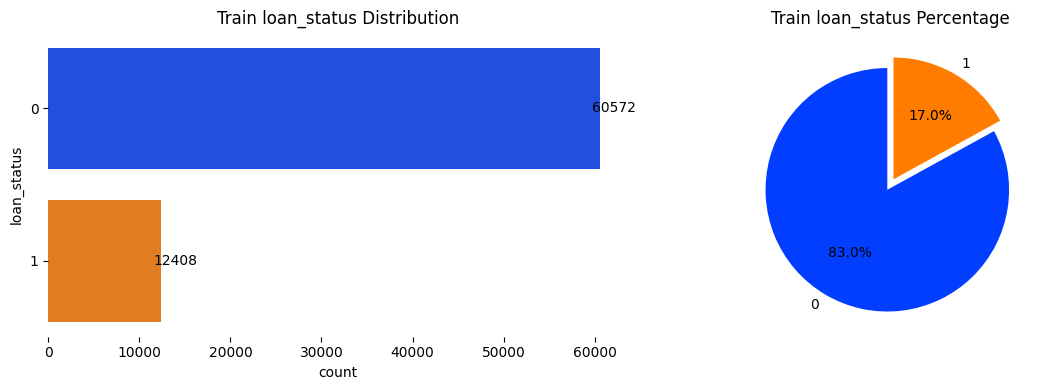

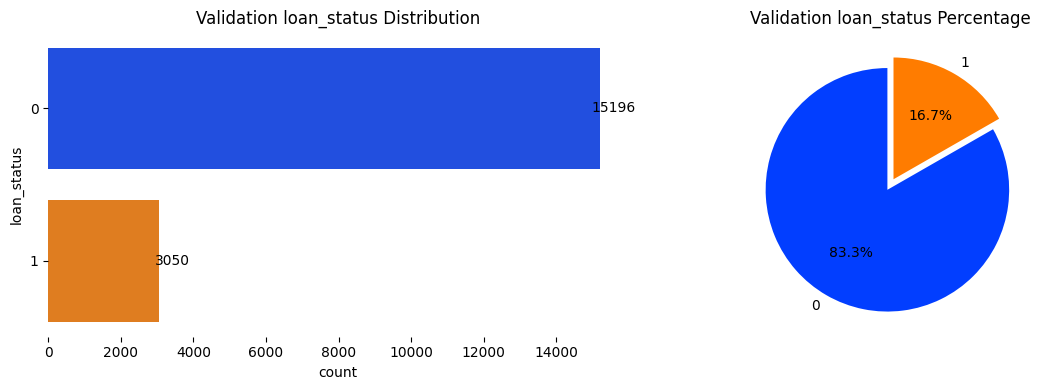

In [ ]:
plt.figure(figsize=(12, 8))  # Adjust the figure size to align them properly

# Train set visualization
plot_target_distribution(y_train, dataset_name="Train", target_name=target_column)

# Validation set visualization
plot_target_distribution(y_val, dataset_name="Validation", target_name=target_column)

#### 4.1.2 Numerical Varibles

In [ ]:
def plot_numerical_distribution(column_name: str, data: pd.DataFrame, axes: [List[plt.Axes]] = None) -> None:
    """
    Plots the distribution and boxplot of a numerical column.

    Args:
    - column_name (str): The name of the numerical column to visualize.
    - data (pd.DataFrame): The dataset containing the column.
    - axes (Optional[List[plt.Axes]]): External subplot axes to avoid misalignment.

    Returns:
    - None (Displays the plots)
    """
    if axes is None:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # Default standalone plots

    # Histogram with KDE
    sns.histplot(data[column_name], bins=20, kde=True, color="darkorchid", ax=axes[0])
    axes[0].set_title(f"Distribution of {column_name}")

    # Boxplot
    sns.boxplot(x=data[column_name], color="orchid", ax=axes[1])
    axes[1].set_title(f"Boxplot of {column_name}")


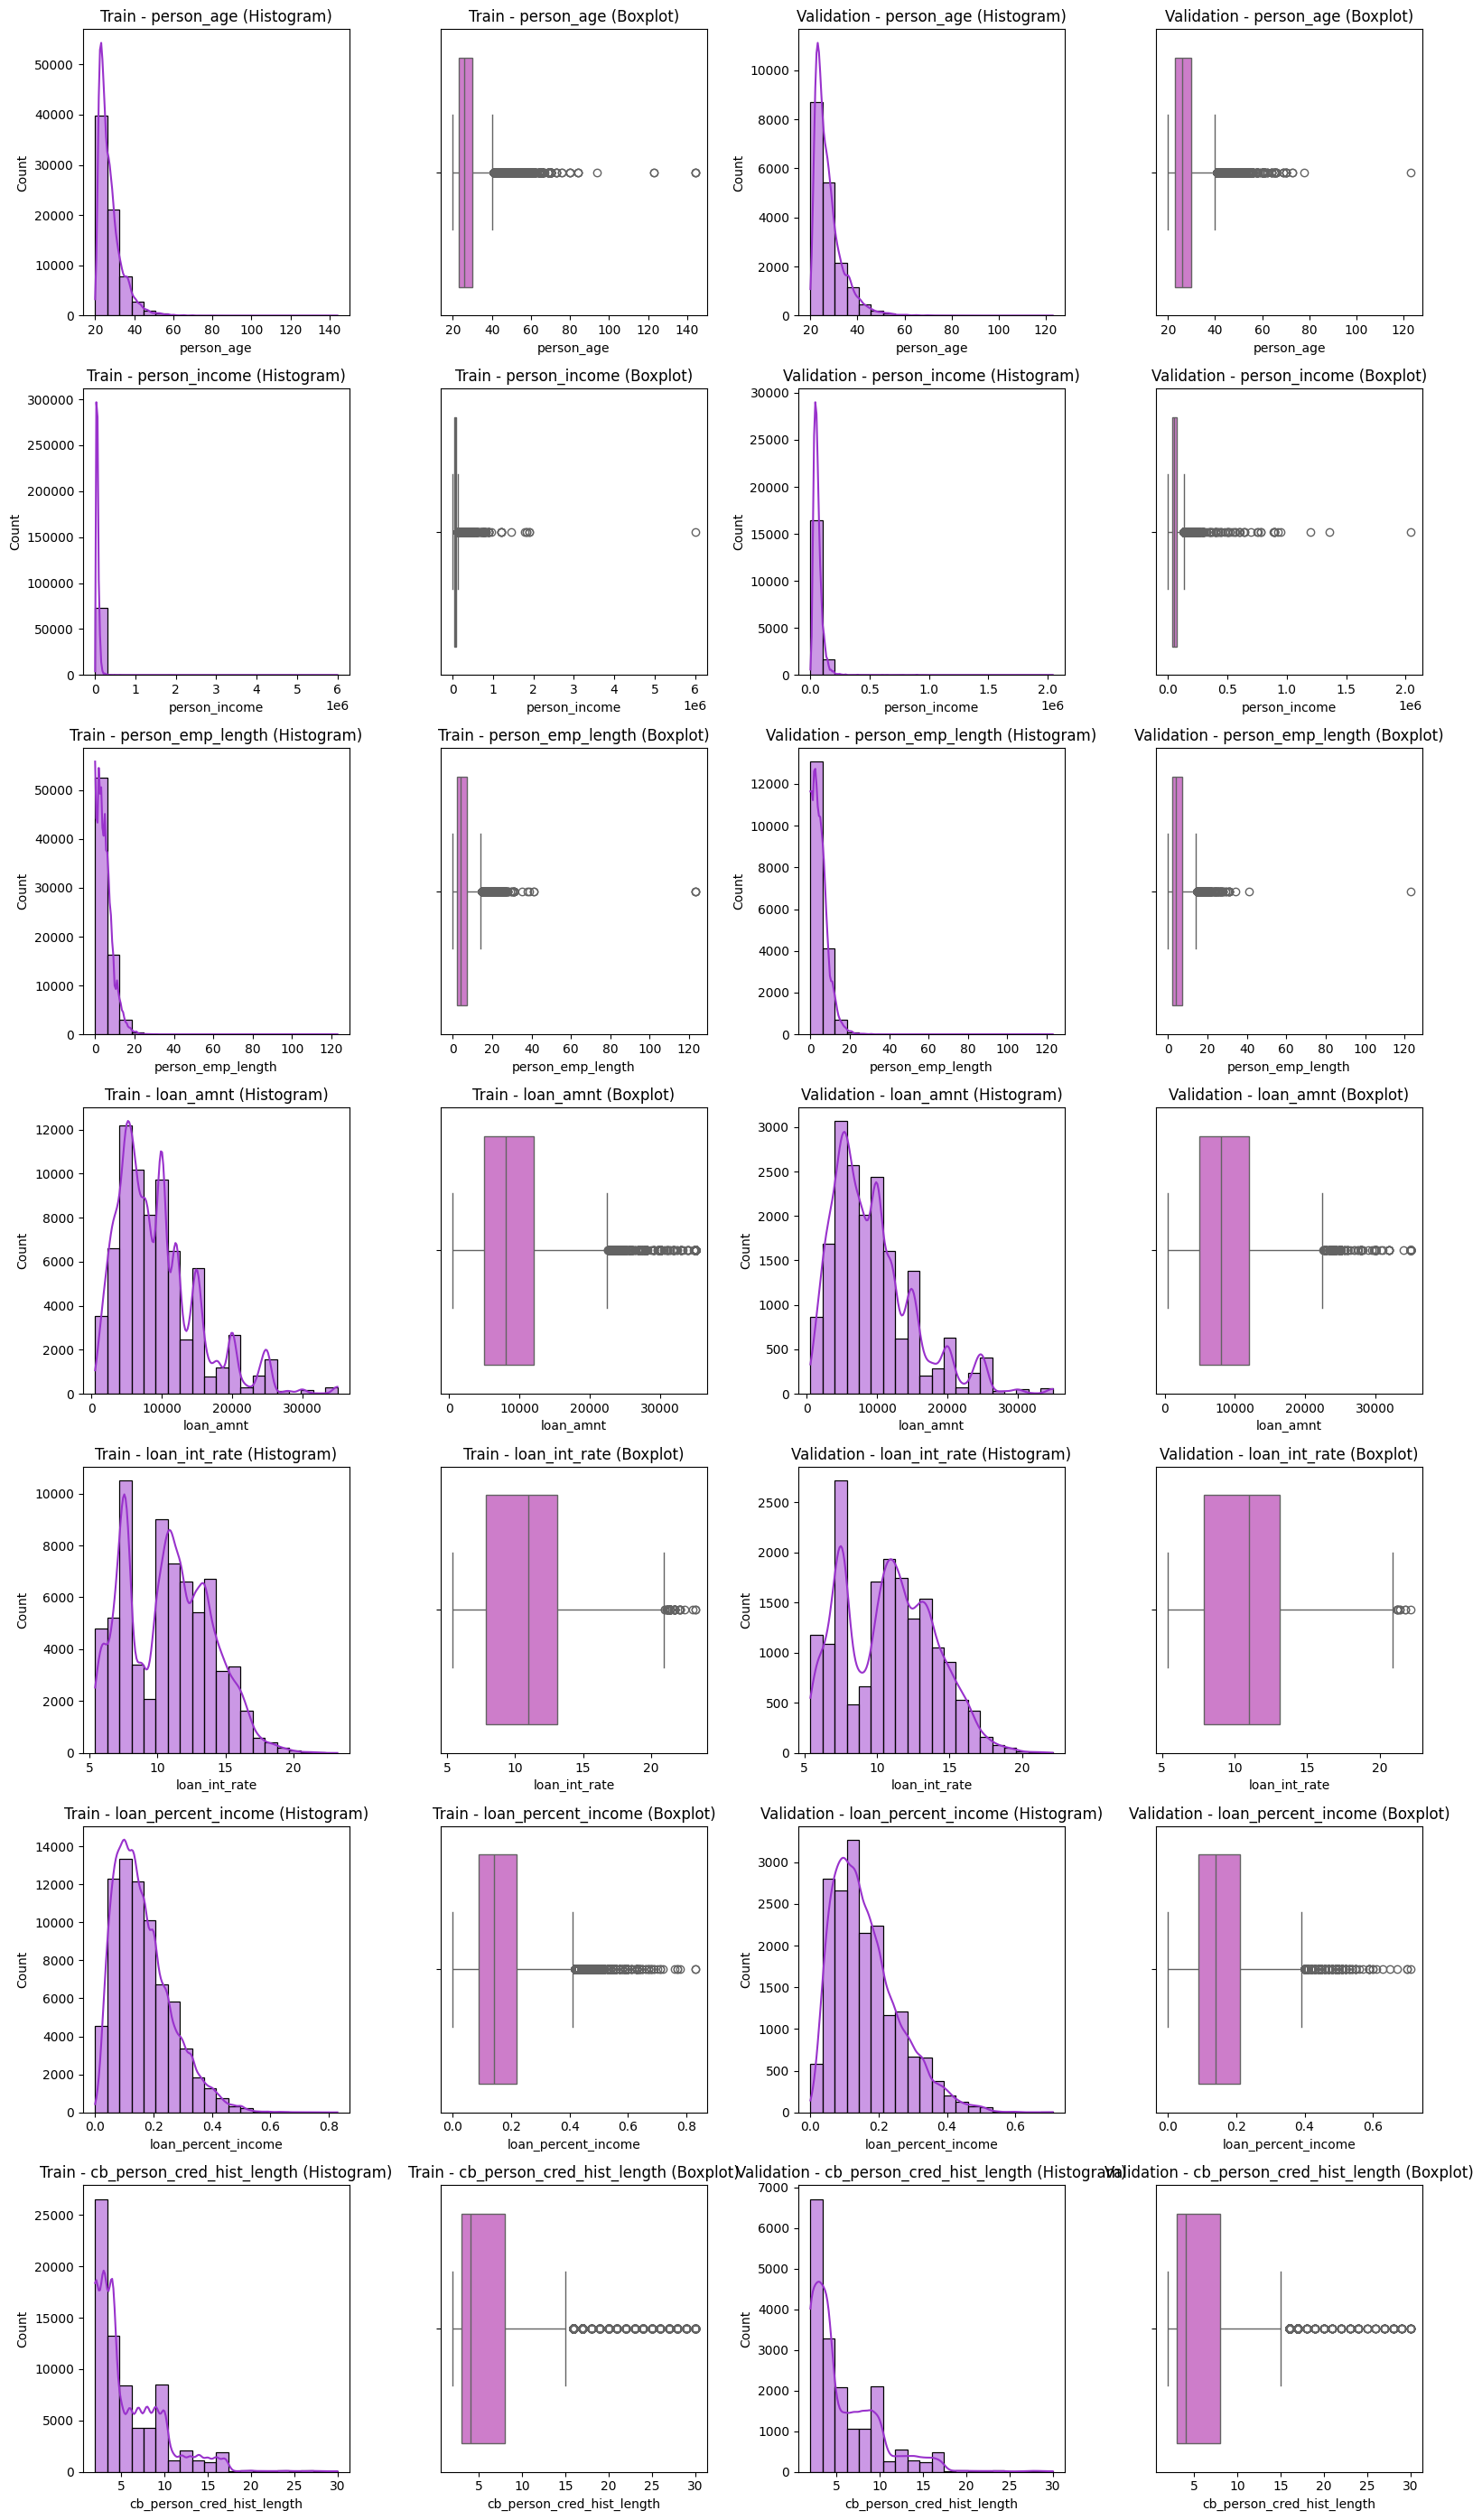

In [ ]:
# Define the numerical columns to be plotted
plotted_columns = [col for col in numerical_columns_no_target if col != 'original']

# Create subplots: Two plots (hist + box) per column for both Train and Validation
fig, axes = plt.subplots(len(plotted_columns), 4, figsize=(16, len(plotted_columns) * 4))

for i, col in enumerate(plotted_columns):
    # Train Data (Left 2 Columns)
    plot_numerical_distribution(col, X_train, axes=axes[i, :2])
    axes[i, 0].set_title(f"Train - {col} (Histogram)")
    axes[i, 1].set_title(f"Train - {col} (Boxplot)")

    # Validation Data (Right 2 Columns)
    plot_numerical_distribution(col, X_val, axes=axes[i, 2:])
    axes[i, 2].set_title(f"Validation - {col} (Histogram)")
    axes[i, 3].set_title(f"Validation - {col} (Boxplot)")

plt.tight_layout()
plt.show()


**Insights:**
Overall, the distribution of train set and validation set is roughly the same.
1. **`person_age`**:  
   - The distribution is skewed towards older applicants, with a some outliers (e.g., age 123).
  
2. **`person_income`**:  
   - Highly skewed with a few extreme outliers in the higher range (up to 6 million).
  
3. **`person_emp_length`**:  
   - Most values are concentrated around the lower range, with a few outliers up to 123 years.
  
4. **`loan_amnt`**:  
   - The distribution is right-skewed, with most loans under 20,000.
  
5. **`loan_int_rate`**:  
   - Some loans having high interest rates (over 20%).
  
6. **`loan_percent_income`**:  
   - Most values are tightly packed under 0.6, with some extreme values.

7. **`cb_person_cred_hist_length`**:  
   - some applicants have a credit history length above 25 years.

#### 4.1.3 Categorical Varibles

In [ ]:
def plot_categorical_distribution(X: pd.DataFrame, column_name: str, dataset_name: str = "Dataset") -> None:
    """
    Plots the distribution of a categorical column from the dataset.

    Args:
    - X (pd.DataFrame): The dataset containing the categorical column to visualize.
    - column_name (str): The name of the categorical column to visualize.
    - dataset_name (str): A label to indicate whether the data is from 'Train' or 'Validation'.

    Returns:
    - None (Displays the plot)
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

    # Count plot
    sns.countplot(y=X[column_name], palette="bright", ax=axes[0])
    axes[0].set_title(f"{dataset_name} {column_name} Distribution")

    # Add count labels
    for p in axes[0].patches:
        axes[0].annotate(f"{int(p.get_width())}",
                         (p.get_width(), p.get_y() + p.get_height() / 2),
                         ha="center", va="center", xytext=(10, 0), textcoords="offset points")

    sns.despine(left=True, bottom=True)

    # Pie chart
    X[column_name].value_counts().plot.pie(
        autopct="%1.1f%%", colors=sns.color_palette("bright"), startangle=90,
        explode=[0.05] * X[column_name].nunique(), ax=axes[1])
    axes[1].set_title(f"{dataset_name} {column_name} Percentage")
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()


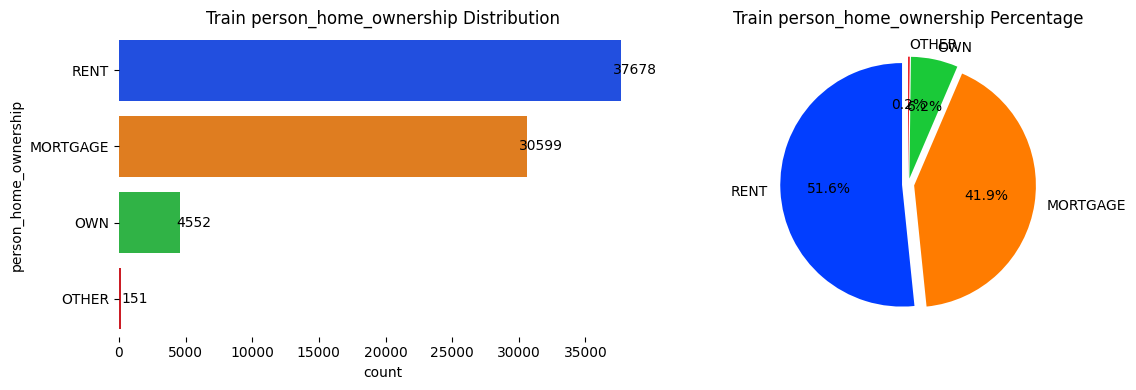

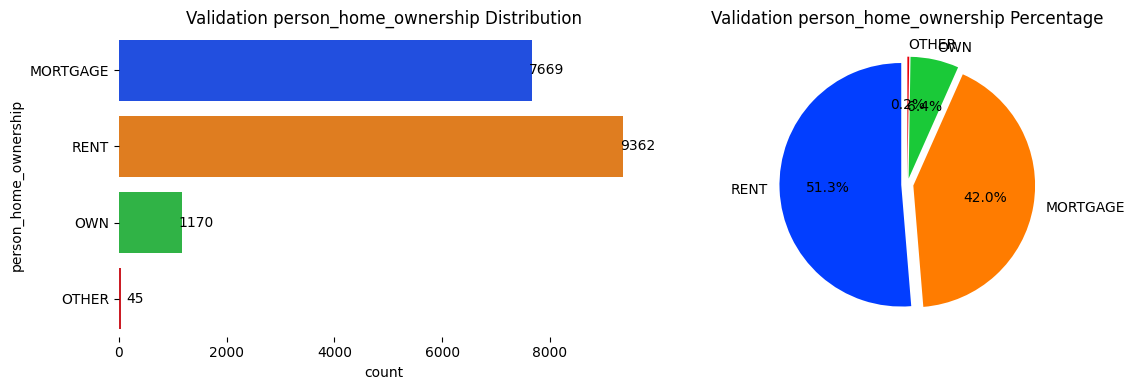

In [ ]:
# Plotting for 'person_home_ownership'
# For Train Data
plot_categorical_distribution(X_train, column_name="person_home_ownership", dataset_name="Train")

# For Validation Data
plot_categorical_distribution(X_val, column_name="person_home_ownership", dataset_name="Validation")


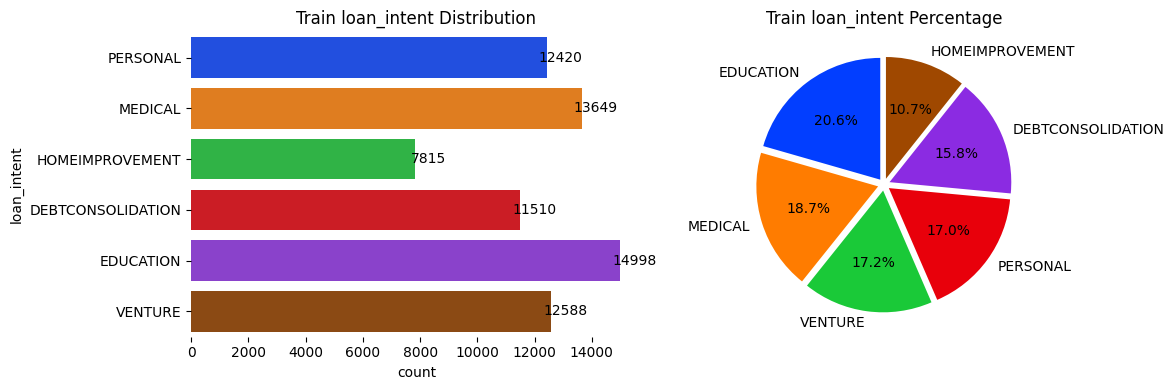

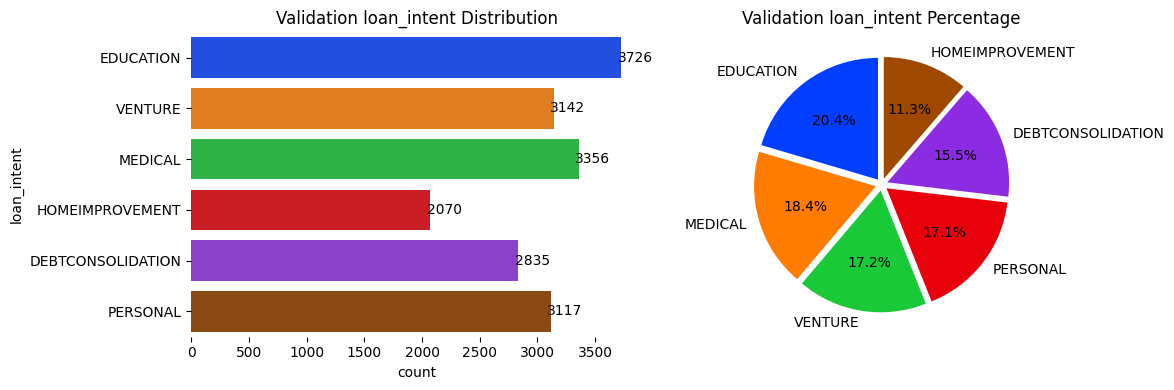

In [ ]:
# Plotting for 'loan_intent'
# For Train Data
plot_categorical_distribution(X_train, column_name="loan_intent", dataset_name="Train")

# For Validation Data
plot_categorical_distribution(X_val, column_name="loan_intent", dataset_name="Validation")


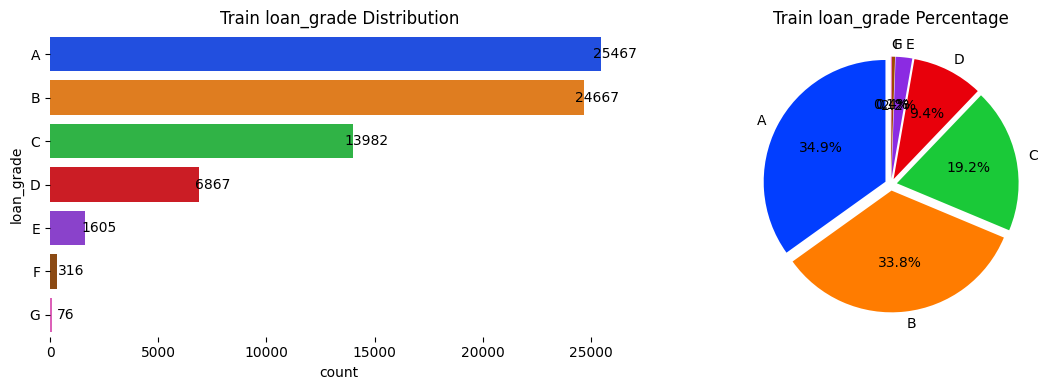

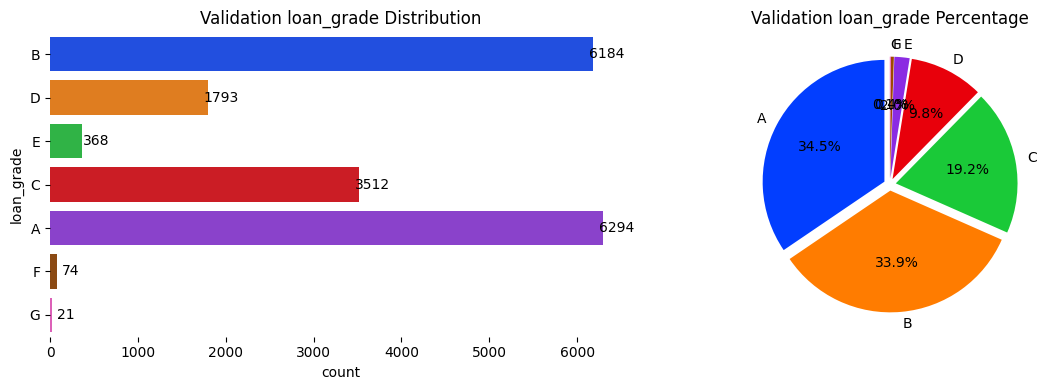

In [ ]:
# Plotting for 'loan_grade'
# For Train Data
plot_categorical_distribution(X_train, column_name="loan_grade", dataset_name="Train")

# For Validation Data
plot_categorical_distribution(X_val, column_name="loan_grade", dataset_name="Validation")

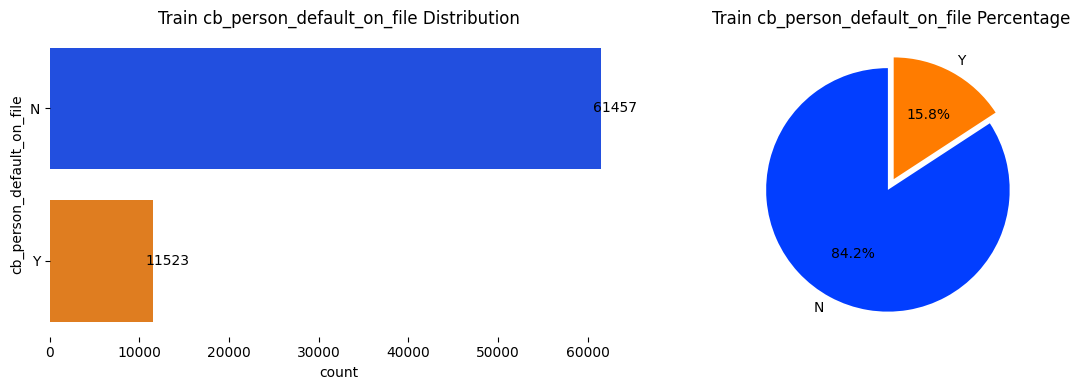

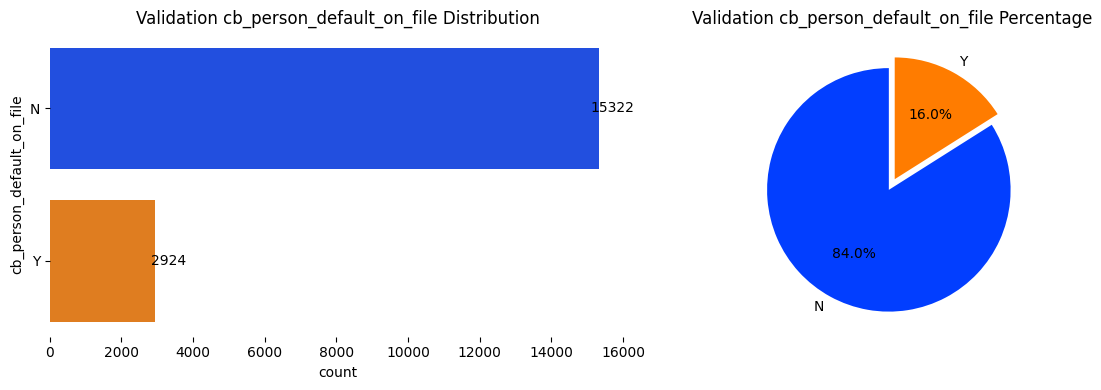

In [ ]:
# Plotting for 'cb_person_default_on_file'
# For Train Data
plot_categorical_distribution(X_train, column_name="cb_person_default_on_file", dataset_name="Train")

# For Validation Data
plot_categorical_distribution(X_val, column_name="cb_person_default_on_file", dataset_name="Validation")

**Insights:**
Overall, the distribution of train set and validation set is roughly the same.

1. **`person_home_ownership`**:
   - The majority of applicants either **rent** or have a **mortgage**.
   - Fewer applicants fall under the categories **'OWN'** or **'OTHER'**.

2. **`loan_intent`**:
   - Most common loan purposes are **'EDUCATION'** and **'MEDICAL'**.
   - Other intents like **'HOMEIMPROVEMENT'** and **'VENTURES'** are less frequent.

3. **`loan_grade`**:
   - Grades **A, B,** and **C** dominate the dataset, with fewer loans in grades **F** and **G**.

4. **`cb_person_default_on_file`**:
   - Most applicants have **'N'** (No prior default), with fewer having **'Y'** (Yes, prior default).


### 4.2 Bivariate Analysis

#### 4.2.1 Numerical vs. Loan Status

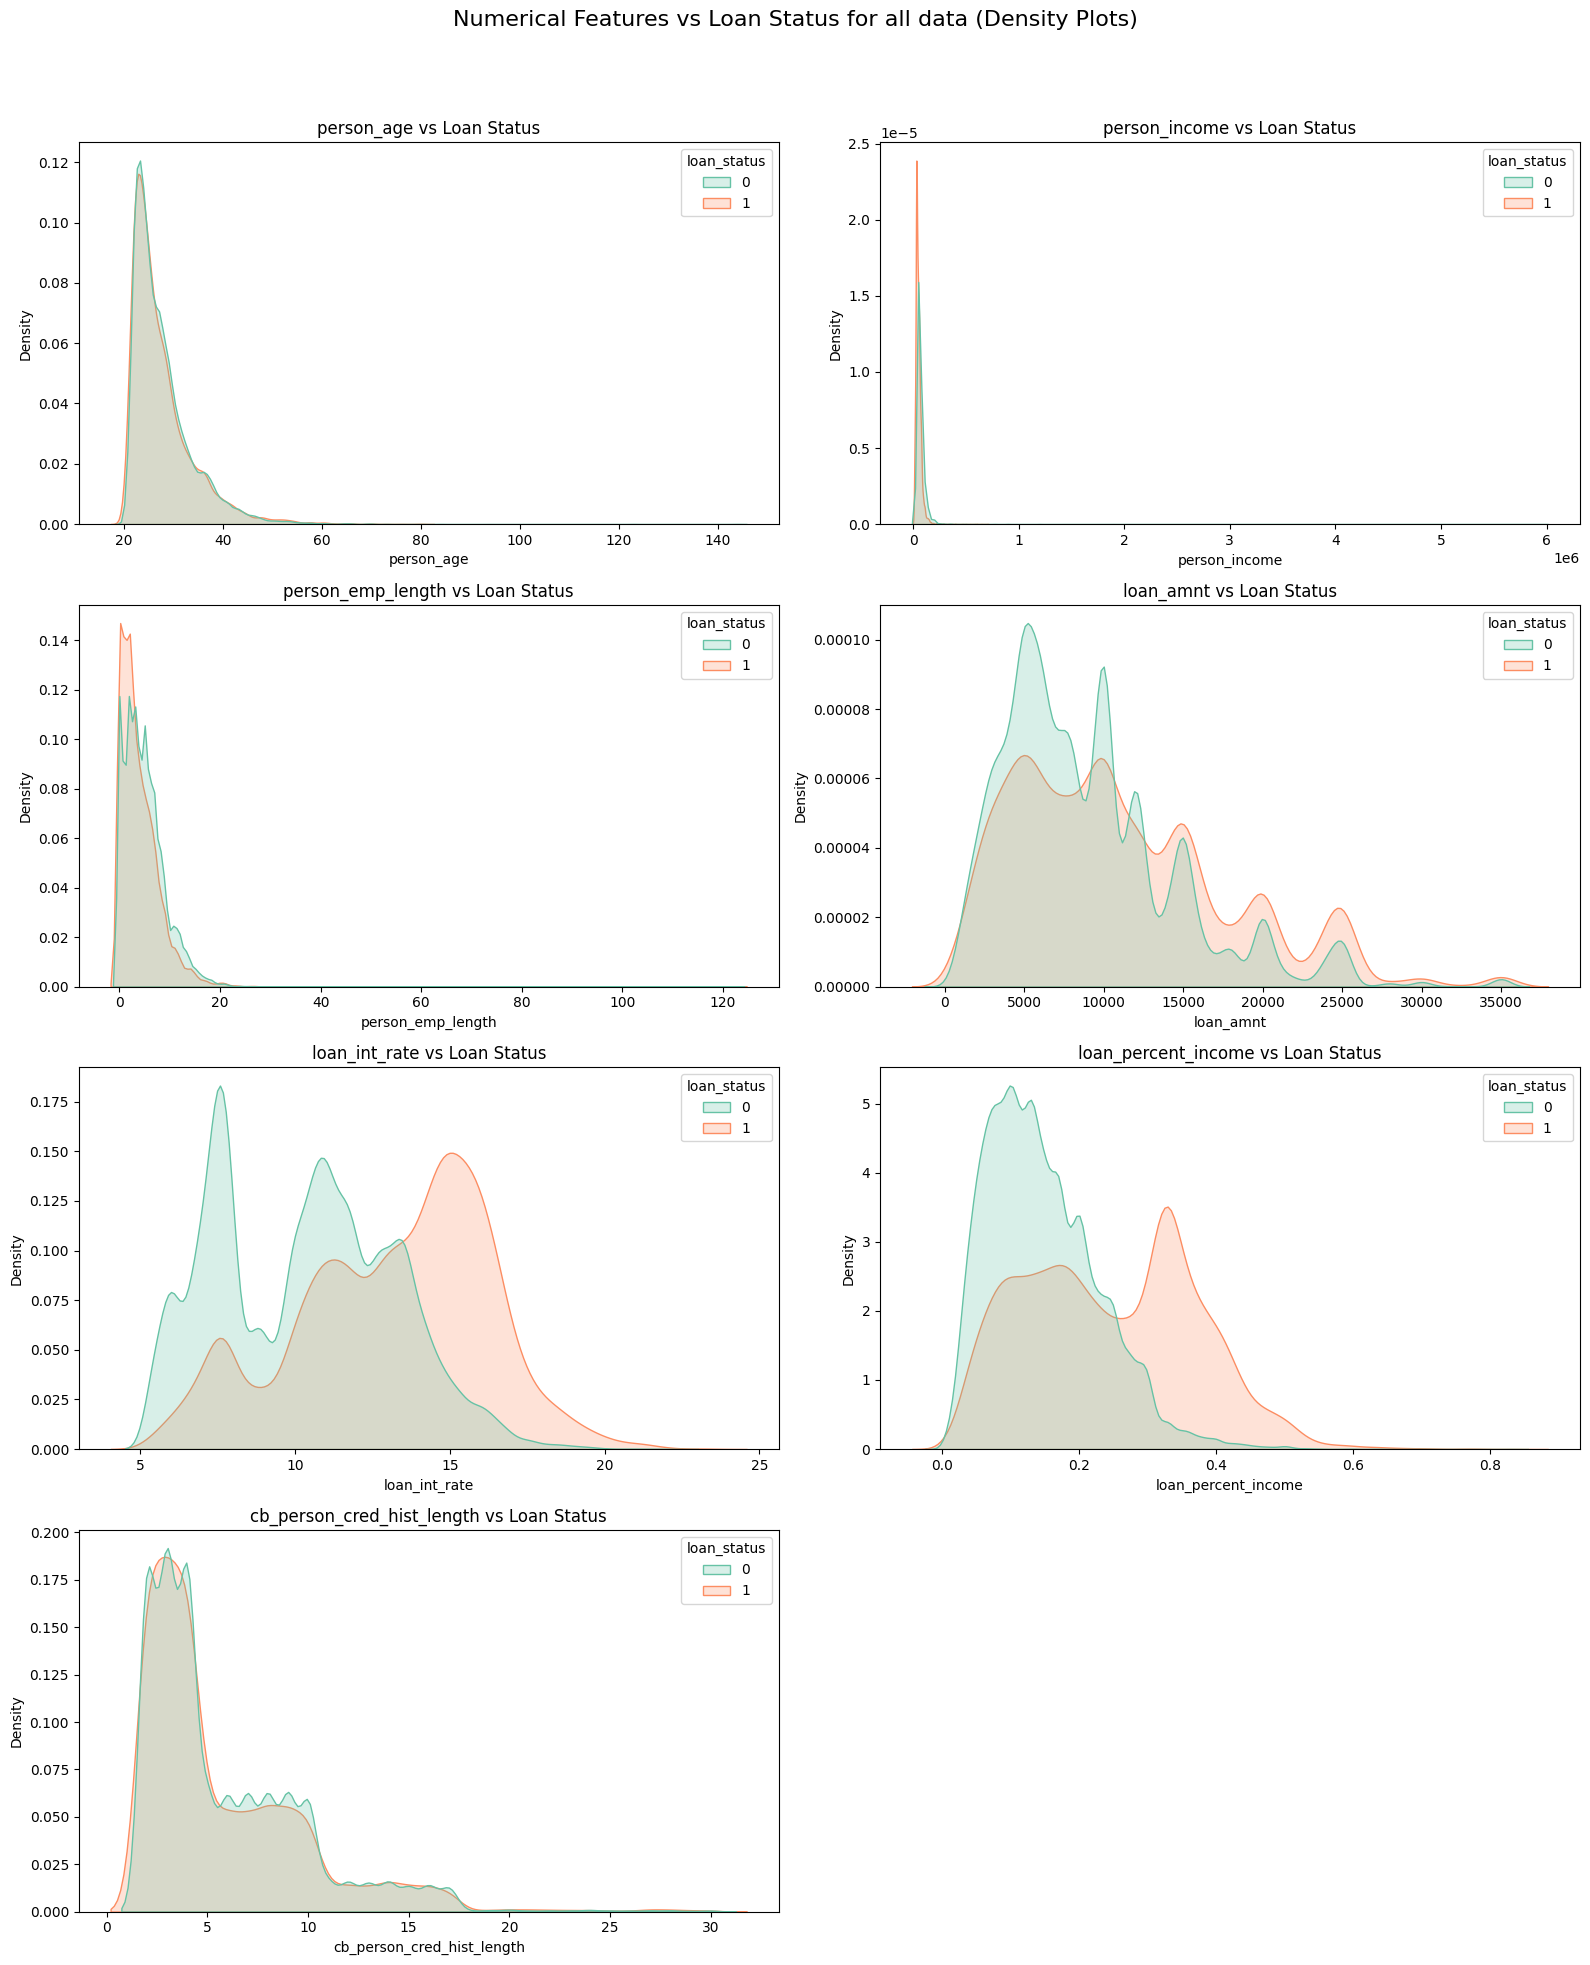

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
fig.suptitle('Numerical Features vs Loan Status for all data (Density Plots)', fontsize=16)

for i, col in enumerate(plotted_columns):
    sns.kdeplot(data=train_data, x=col, hue='loan_status', ax=axes[i//2, i%2], fill=True, common_norm=False, palette='Set2')
    axes[i//2, i%2].set_title(f'{col} vs Loan Status')
    axes[i//2, i%2].set_xlabel(col)
    axes[i//2, i%2].set_ylabel('Density')

fig.delaxes(axes[3, 1])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Observations from Numerical Features vs Loan Status (Density Plots):**

1. **`person_age` vs Loan Status**:
   - Younger applicants (20-40 years) dominate the dataset, but the approval rate (loan status = 1) seems relatively consistent across age groups.
   - Older applicants (60+ years) have fewer applications, but their approval rate appears slightly lower.

2. **`person_emp_length` vs Loan Status**:
   - Applicants with shorter employment lengths (0-10 years) have the highest density, but the approval rate is relatively consistent across employment lengths.
   - Longer employment lengths (20+ years) show fewer applications, with a slight decrease in approval rates.

3. **`loan_int_rate` vs Loan Status**:
   - Loans with lower interest rates (5-10%) have a lower approval rate.
   - As the interest rate increases (15-25%), the approval rate increases significantly.

4. **`cb_person_cred_hist_length` vs Loan Status**:
   - Applicants with shorter credit histories (0-10 years) dominate the dataset, but the approval rate is relatively consistent across credit history lengths.
   - Longer credit histories (20+ years) show fewer applications, with a slight increase in approval rates.

5. **`person_income` vs Loan Status**:
   - Lower-income applicants (0-2 units) dominate the dataset, but the approval rate is relatively consistent across income levels.
   - Higher-income applicants (4+ units) show fewer applications, with a slight increase in approval rates.

6. **`loan_amnt` vs Loan Status**:
   - Smaller loan amounts (0-10,000) have the highest density and a better approval rate.
   - As the loan amount increases (20,000+), the approval rate decreases.

7. **`loan_percent_income` vs Loan Status**:
   - Loans that constitute a smaller percentage of the applicant's income (0.0-0.4) have a higher density and a better approval rate.
   - As the loan percentage of income increases (0.6+), the approval rate decreases significantly.

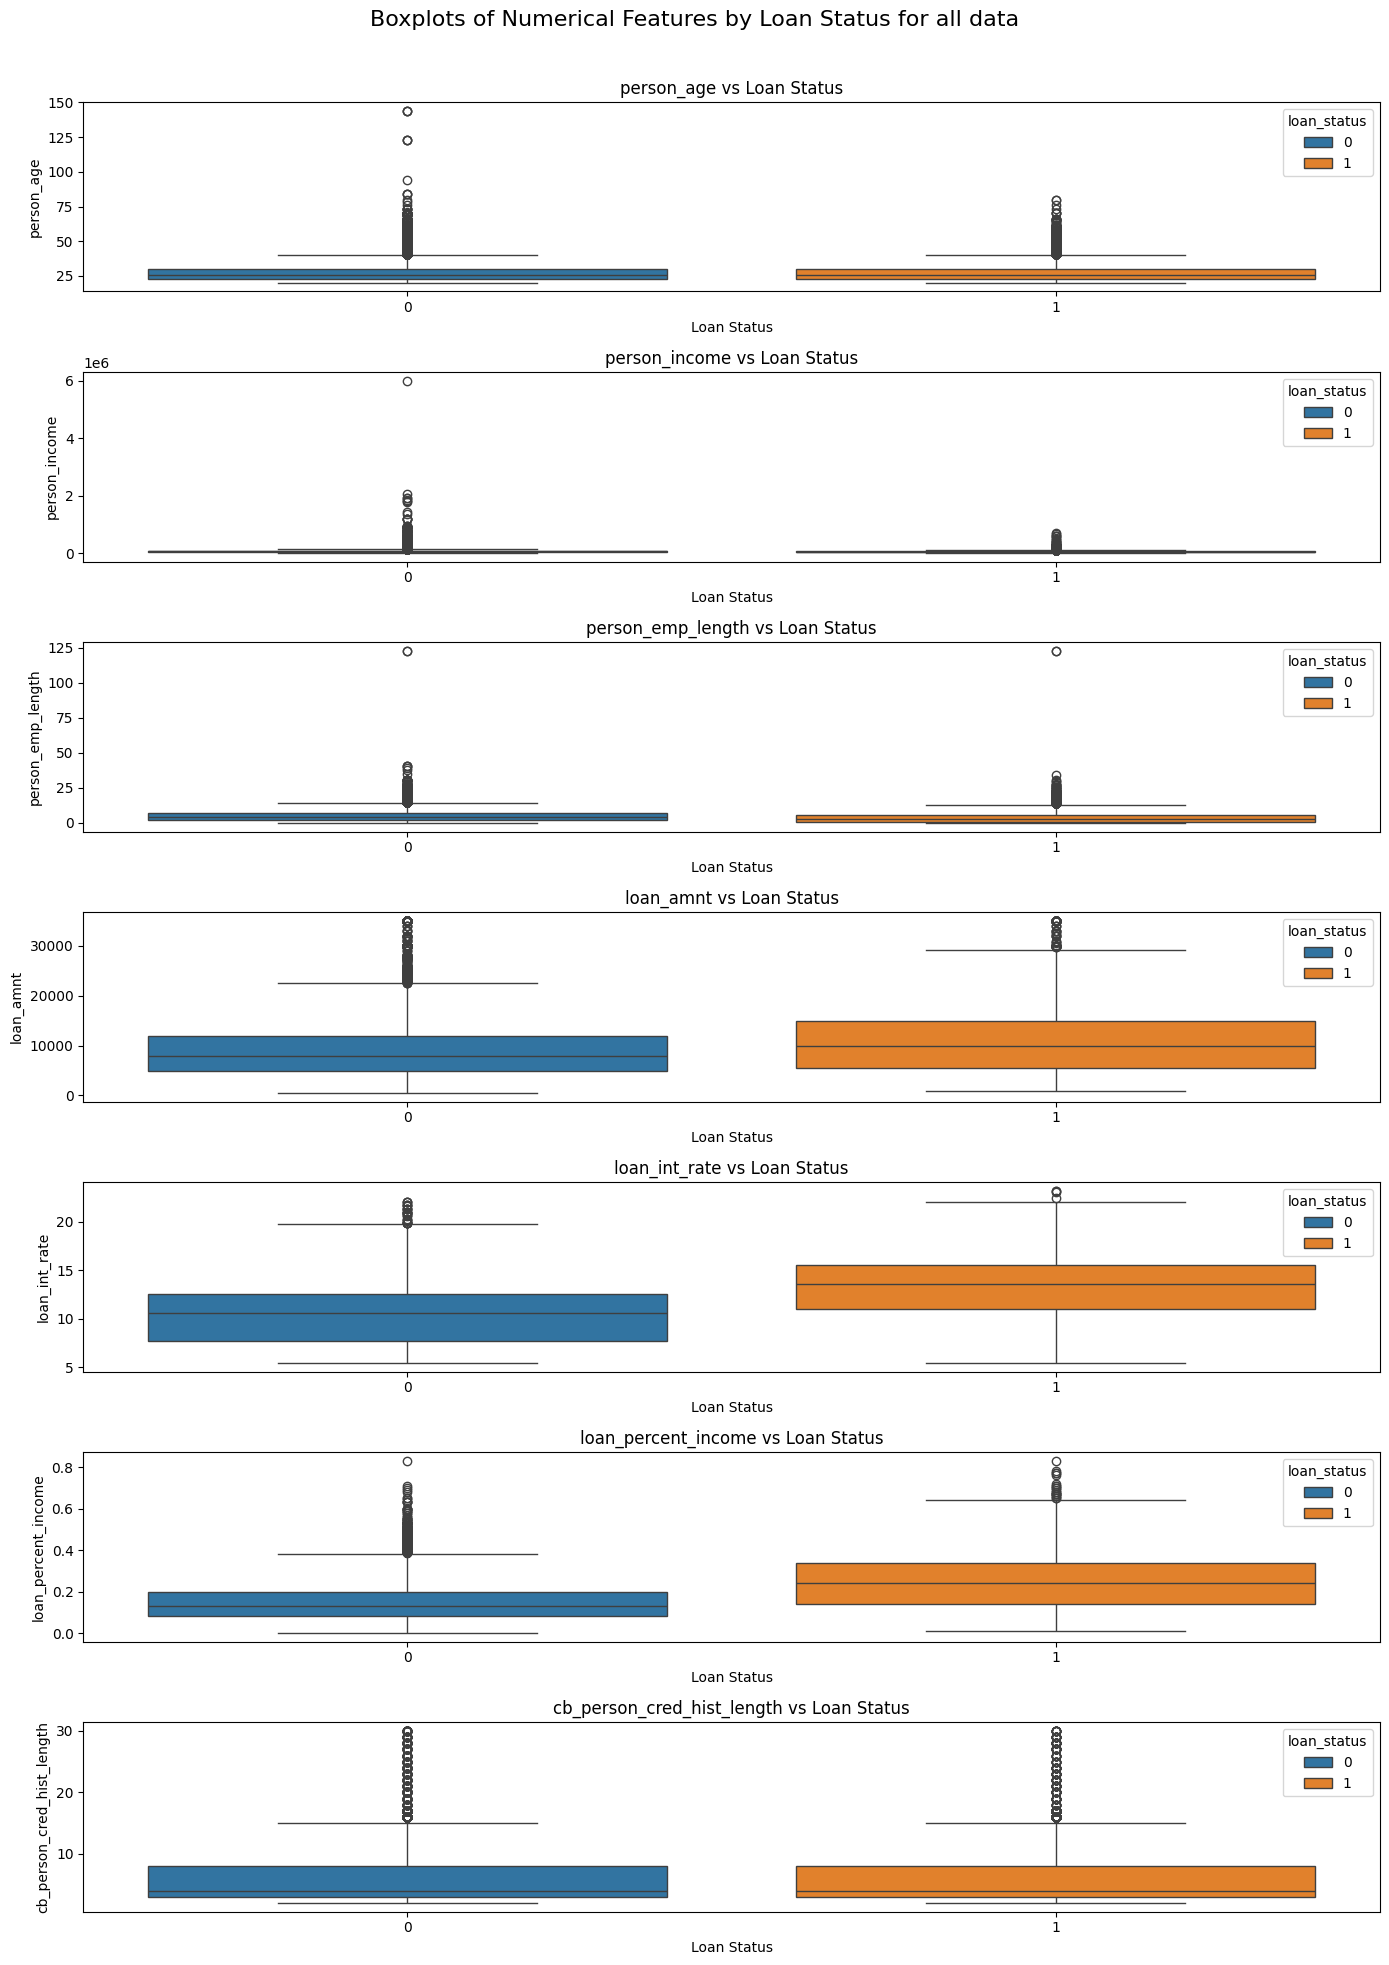

In [ ]:
fig, axes = plt.subplots(len(plotted_columns), 1, figsize=(14, 20))
fig.suptitle('Boxplots of Numerical Features by Loan Status for all data', fontsize=16)

for i, feature in enumerate(plotted_columns):
    sns.boxplot(data=train_data, x='loan_status', y=feature, ax=axes[i],hue='loan_status')
    axes[i].set_title(f'{feature} vs Loan Status')
    axes[i].set_xlabel('Loan Status')
    axes[i].set_ylabel(feature)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

#### 4.2.2 Categorical vs. Loan Status

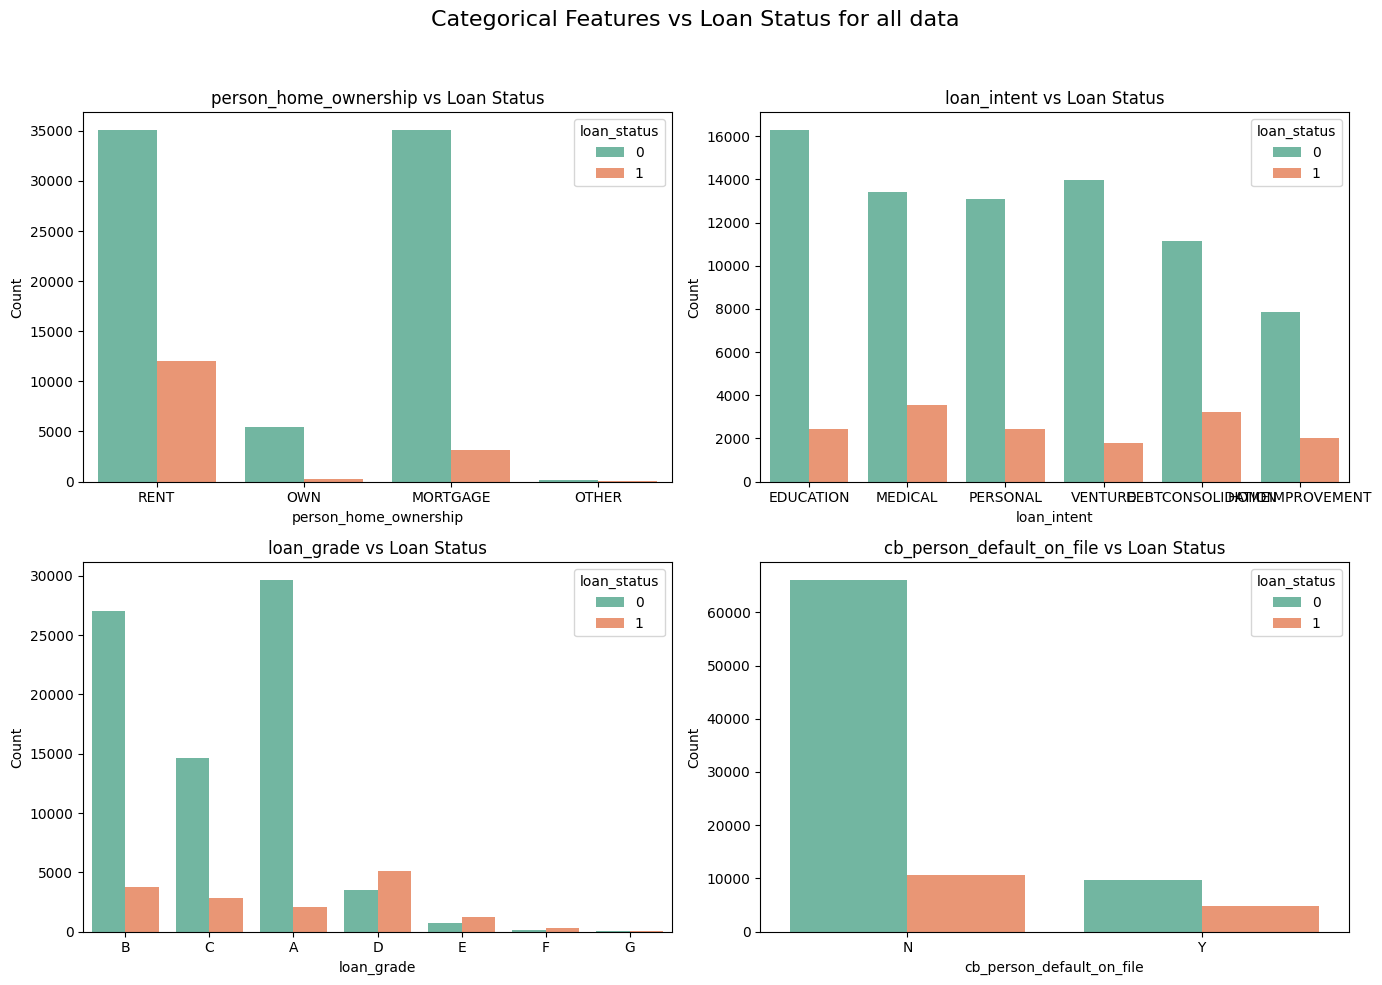

In [ ]:
categorical_columns = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Categorical Features vs Loan Status for all data', fontsize=16)

for i, col in enumerate(categorical_columns):
    sns.countplot(x=col, hue='loan_status', data=train_data, ax=axes[i//2, i%2], palette='Set2')
    axes[i//2, i%2].set_title(f'{col} vs Loan Status')
    axes[i//2, i%2].set_xlabel(col)
    axes[i//2, i%2].set_ylabel('Count')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Observations from Categorical Features vs Loan Status:**

1. **`person_home_ownership`**:
   - Applicants with **RENT** or **MORTGAGE** tend to have more loans. However, approval rate (loan status = 1) of  **RENT** is higher than **MORTGAGE**.

2. **`loan_intent`**:
   - **EDUCATION** and **MEDICAL** loans dominate the dataset, but approvals are more frequent in categories like **DEBTCONSOLIDATION** and **HOMEIMPROVEMENT**.

3. **`loan_grade`**:
   - Loan grades **A, B,** and **C** have the highest volume, but the approval rate seems to increase as the loan grade shifts to **D, E, F,** and **G**.


### 4.3 Multivariate Analysis

Uncomment if you want to see. it takes a quite long time.

In [ ]:
# Pairplot of numerical features
# numerical_columns_with_target = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_status']

# sns.pairplot(train_data[numerical_columns_with_target], hue='loan_status', palette='Set2')
# plt.show()

**Observations from Pairplots:**<br>

*Few pairs of features seems to have differentiation of target like Age-Income, Loan Percent Income - Credit History Length. Some feature engineering on these features will be conducted in a later section.*


## 5. Feature Engineering

### 5.1 Imputation of Missing Values

| Situation                          | Recommended Method                         |
|------------------------------------|-------------------------------------------|
| Few missing values (random)       | Mean, Median, Mode                        |
| Correlated features               | KNN, Iterative Imputation                 |
| Missing values in many columns    | Regression, MICE, ML-based                |
| Complex patterns                  | Deep Learning (Autoencoders, GANs)        |
| Time-series data                  | Forward Fill, Interpolation               |
| Too many missing values           | Drop the feature                          |


In [ ]:
def store_missing_rows(df: pd.DataFrame, features: List) -> Dict:
    '''Function stores where missing values are located for given set of features'''
    missing_rows = {feature: df[df[feature].isnull()].index for feature in features}
    return missing_rows

cb_params = {
    'iterations': 500,# subject to change
    'grow_policy': 'Depthwise',
    'bootstrap_type': 'Bayesian',
    'od_type': 'IncToDec',
    'eval_metric': 'MAE',
    'loss_function': 'MAE',
    'random_state': 42,
    'task_type': device.upper(),
}

def fill_missing_numerical(df: pd.DataFrame, max_iterations: int = 10) -> pd.DataFrame:
    '''
    Iterative Missing Imputer: Fills missing numerical values iteratively using CatBoostRegressor.

    Parameters:
        df (pd.DataFrame): Input DataFrame with missing values.
        max_iterations (int): Maximum number of iterations for imputation.

    Returns:
        pd.DataFrame: DataFrame with imputed missing values.
    '''
    df_temp = df.copy()  # Work on a copy of the DataFrame

    # Identify features with missing values
    features = [f for f in df_temp.columns if df_temp[f].isna().sum() > 0]
    if not features:
        return df_temp  # Return early if no missing values exist

    # Step 1: Store the instances with missing values in each feature
    missing_rows = store_missing_rows(df_temp, features)

    # Identify categorical features
    cat_features = [f for f in df_temp.columns if not pd.api.types.is_numeric_dtype(df_temp[f])]

    # Dictionary to store MAE values for each feature across iterations
    dictionary = {feature: [] for feature in features}

    # Step 2: Convert categorical features to numerical **only once**
    replace_dict = {}
    rev_replace_dict = {}
    for col in cat_features:
        df_temp[col] = df_temp[col].astype(str)
        unique_cats = df_temp[col].unique()
        int_cat = {k: v for v, k in enumerate(unique_cats)}  # Forward mapping
        rev_int_cat = {v: k for k, v in int_cat.items()}  # Reverse mapping
        df_temp[col] = df_temp[col].replace(int_cat)
        replace_dict[col] = int_cat
        rev_replace_dict[col] = rev_int_cat

    # Step 3: Iteratively impute missing values
    for iteration in tqdm(range(max_iterations), desc="Iterations"):
        for feature in features:
            rows_miss = missing_rows[feature]

            # Split data into missing and non-missing rows
            missing_temp = df_temp.loc[rows_miss].copy()
            non_missing_temp = df_temp.drop(index=rows_miss).copy()

            # Store previous predictions (for error calculation)
            y_pred_prev = missing_temp[feature]

            # Drop the target feature (current feature with missing values)
            missing_temp = missing_temp.drop(columns=[feature])

            # Define training data
            X_train = non_missing_temp.drop(columns=[feature])
            y_train = non_missing_temp[[feature]]

            # Step 4: Use CatBoostRegressor to predict missing values
            model = CatBoostRegressor(**cb_params)
            model.fit(X_train, y_train, cat_features=cat_features, verbose=False)

            # Step 5: Predict and fill missing values
            y_pred = np.array(model.predict(missing_temp))
            df_temp.loc[rows_miss, feature] = y_pred

            # Step 6: Calculate and store MAE
            if iteration == 0:
                error_minimize = mean_absolute_error(y_pred, y_pred * 1.5)  # Initial seed
            else:
                error_minimize = mean_absolute_error(y_pred, y_pred_prev)
            dictionary[feature].append(error_minimize)

    # Step 7: Restore categorical features after all iterations
    for col in cat_features:
        df_temp[col] = df_temp[col].replace(rev_replace_dict[col])

    # Step 8: Plot MAE minimization
    for feature, values in dictionary.items():
        values = np.array(values) / sum(values)
        iterations = range(1, len(values) + 1)
        plt.plot(iterations, values, label=feature)

    plt.xlabel('Iterations')
    plt.ylabel('MAE')
    plt.title('Minimization of MAE with iterations')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

    return df_temp


Iterations:   0%|          | 0/5 [00:00<?, ?it/s]Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Iterations:  20%|██        | 1/5 [00:14<00:56, 14.16s/it]Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Iterations:  40%|████      | 2/5 [00:27<00:41, 13.72s/it]Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Iterations:  60%|██████    | 3/5 [00:40<00:26, 13.44s/it]Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Iterations:  80%|████████  | 4/5 [00:53<00:13, 13.27s/it]Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Iterations: 100%|██████

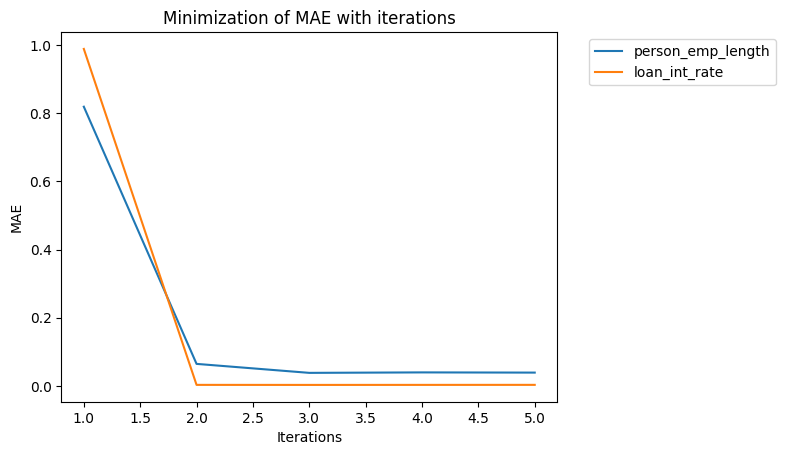

CPU times: user 1min 10s, sys: 36.5 s, total: 1min 46s
Wall time: 1min 7s


In [ ]:
%%time
# Fill missing values
X_imputed = fill_missing_numerical(X, max_iterations=5)

This code is a **custom iterative missing value imputation function** designed to fill missing numerical values in a dataset using the **CatBoostRegressor** algorithm. It works iteratively to improve the accuracy of the imputed values. Let’s break it down step by step:

---

### **1. Key Functions**


#### **`store_missing_rows(df, features)`**
- **Purpose**: Stores the rows where missing values are located for a given set of features.
- **Output**: A dictionary where each key is a feature, and the value is a DataFrame containing rows with missing values for that feature.

#### **`fill_missing_numerical(train, test, target, max_iterations=10)`**
- **Purpose**: Iteratively fills missing numerical values in the `train` and `test` datasets using the **CatBoostRegressor**.
- **Steps**:
  1. Combines `train` and `test` datasets into a single DataFrame (`df`) for easier processing.
  2. Identifies features with missing values.
  3. Iteratively predicts missing values using CatBoostRegressor and updates the dataset.
  4. Plots the minimization of **Mean Absolute Error (MAE)** over iterations for each feature.
  5. Returns the imputed `train` and `test` datasets.

---

### **2. Parameters and Variables**

#### **`cb_params`**
- A dictionary of hyperparameters for the **CatBoostRegressor**:
  - `iterations`: Number of boosting iterations.
  - `grow_policy`: How the tree grows (e.g., `Depthwise`).
  - `bootstrap_type`: Method for sampling weights (e.g., `Bayesian`).
  - `od_type`: Overfitting detector type (e.g., `IncToDec`).
  - `eval_metric`: Evaluation metric (e.g., `MAE`).
  - `loss_function`: Loss function to optimize (e.g., `MAE`).
  - `random_state`: Seed for reproducibility.
  - `task_type`: Device to use (e.g., `CPU` or `GPU`).

#### **`max_iterations`**
- The maximum number of iterations for the imputation process.

#### **`features`**
- A list of features in the dataset that have missing values.

#### **`missing_rows`**
- A dictionary storing rows with missing values for each feature.

#### **`dictionary`**
- A dictionary to store the **MAE** values for each feature across iterations. Used for plotting.

---

### **3. Workflow of `fill_missing_numerical`**

#### **Step 1: Combine `train` and `test` Data**
- The `train` and `test` datasets are combined into a single DataFrame (`df`) for easier handling of missing values.

#### **Step 2: Identify Features with Missing Values**
- Features with missing values are identified and stored in the `features` list.

#### **Step 3: Store Rows with Missing Values**
- The `store_missing_rows` function is used to store the rows where each feature has missing values.

#### **Step 4: Iterative Imputation**
- For each iteration:
  1. **Categorical Features**: Convert categorical features to numerical representations using integer encoding.
  2. **Split Data**: Split the data into:
     - `non_missing_temp`: Rows without missing values for the current feature.
     - `missing_temp`: Rows with missing values for the current feature.
  3. **Train CatBoostRegressor**: Train a CatBoostRegressor model on `non_missing_temp` to predict the missing values.
  4. **Predict Missing Values**: Use the trained model to predict missing values for the current feature.
  5. **Update Dataset**: Replace missing values in the dataset with the predicted values.
  6. **Calculate Error**: Compute the **MAE** between the current and previous predictions (to track convergence).
  7. **Store Error**: Store the MAE values for plotting.

#### **Step 5: Plot MAE Minimization**
- After all iterations, plot the **MAE** values for each feature to visualize how the error minimized over iterations.

#### **Step 6: Return Imputed Data**
- Split the imputed dataset back into `train` and `test` and return them.

---

### **4. Key Points**

#### **Why Use CatBoostRegressor?**
- CatBoost is a powerful gradient boosting algorithm that handles categorical features natively and is robust to overfitting.
- It is well-suited for this task because it can handle mixed data types (numerical and categorical) and missing values.

#### **Why Iterative Imputation?**
- Iterative imputation improves the accuracy of filled values by repeatedly refining predictions based on updated data.

#### **Error Minimization**
- The **MAE** is used to track the convergence of imputed values. The goal is to minimize this error over iterations.

#### **Handling Categorical Features**
- Categorical features are converted to numerical representations using integer encoding before training the model.

---


### **6. Output**
- The `train` and `test` datasets will have their missing numerical values filled.
- A plot showing the minimization of **MAE** over iterations for each feature.

In [ ]:
#Split the imputed data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

# Display the shapes of the training and validation sets
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (72980, 12)
X_val shape: (18246, 12)
y_train shape: (72980,)
y_val shape: (18246,)


### 5.2 Handle Outliers

In [ ]:
def log_transformation(train: pd.DataFrame, column: str) -> pd.DataFrame:
    '''
    Log Transformation after MinMax Scaling (keeps data between 0 and 1)
    '''
    train["log_" + column] = np.log1p(train[column])
    return train

def sqrt_transformation(train: pd.DataFrame, column: str) -> pd.DataFrame:
    '''
    Square Root Transformation
    '''
    train["sqrt_" + column] = np.sqrt(train[column])
    return train

def box_cox_transformation(train: pd.DataFrame, column: str, save_path: str = None) -> pd.DataFrame:
    '''
    Box-Cox transformation
    '''
    epsilon = 1e-9
    transformer = PowerTransformer(method='box-cox')
    train["bx_cx_" + column] = train[column].apply(lambda x: x if x > 0 else epsilon)
    train["bx_cx_" + column] = transformer.fit_transform(train[["bx_cx_" + column]])

    if save_path:
        joblib.dump(transformer, save_path + "box_cox_" + column + ".joblib")

    return train

def power_transform(x: np.ndarray, power: float) -> np.ndarray:
    '''
    Power transformation function
    '''
    return np.power(x + 1 - np.min(x), power)

def power_transformation(train: pd.DataFrame, column: str, power: float, save_path: str = None) -> pd.DataFrame:
    '''
    Power transformation
    '''
    transformer = FunctionTransformer(power_transform, kw_args={'power': power})
    train["pow" + str(power) + "_" + column] = transformer.fit_transform(train[[column]])

    if save_path:
        joblib.dump(transformer, save_path + "power_" + str(power) + "_" + column + ".joblib")

    return train

def evaluate_transformations(train: pd.DataFrame, columns: List[str], target: str) -> List[Tuple[str, float]]:
    '''
    Evaluate transformations using a single-variable model
    '''
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    roc_scores: List[Tuple[str, float]] = []

    for f in columns:
        X = train[[f]].values
        y = train[target].values

        rocs: List[float] = []
        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X[train_idx], y[train_idx]
            x_val, y_val = X[val_idx], y[val_idx]
            model = LogisticRegression()
            model.fit(X_train, y_train)
            y_pred = model.predict_proba(x_val)[:, 1]
            rocs.append(roc_auc_score(y_val, y_pred))
        roc_scores.append((f, np.mean(rocs)))

    return roc_scores

def transformer(
    train: pd.DataFrame,
    cont_cols: List[str],
    target: str,
    save_path: str
) -> Tuple[pd.DataFrame, Dict[str, str], float, str]:
    """
    Apply multiple transformations to the given columns and evaluate their performance using a single-variable model.

    Parameters:
    train (DataFrame): Training data.
    cont_cols (list): List of continuous columns to transform.
    target (str): Target variable.
    save_path (str): Path to save the transformers.

    Returns:
    tuple: A tuple containing:
        - Transformed training data (DataFrame).
        - Dictionary of best columns (Dict[str, str]).
        - Overall best ROC AUC score (float).
        - Overall best column (str).
    """
    unimp_cols: Dict[str, List[str]] = {}
    overall_best_score: float = 0.0
    overall_best_col: str = 'none'
    best_cols: Dict[str, str] = {}

    table = PrettyTable()
    table.field_names = ['Feature', 'Original AUC Score', 'Transformation', 'Transformed ROC AUC Score']

    # Create a MinMaxScaler object
    scaler = MinMaxScaler()

    train_true = train.copy()

    # Fit and transform the data
    train[cont_cols] = scaler.fit_transform(train[cont_cols])

    # Save the scaler object
    joblib.dump(scaler, save_path + 'fe_scaler.joblib')

    for col in cont_cols:
        # Apply transformations
        train = log_transformation(train, col)
        train = sqrt_transformation(train, col)
        train = box_cox_transformation(train, col, save_path)
        train = power_transformation(train, col, 0.25, save_path)
        train = power_transformation(train, col, 2, save_path)

        # Evaluate transformations
        transformation_list = [col, "log_" + col, "sqrt_" + col, "bx_cx_" + col, "pow0.25_" + col, "pow2_" + col]
        scores = evaluate_transformations(train, transformation_list, target)

        # Update best columns and scores
        best_col, best_score = max(scores, key=lambda x: x[1])

        if col == best_col:
            train[col] = train_true[col]

        best_cols[col] = best_col
        unimp_cols[col] = [f for f in transformation_list if f != best_col]
        if best_score > overall_best_score:
            overall_best_score = best_score
            overall_best_col = best_col

        # Print results
        orig_roc = [s[1] for s in scores if s[0] == col][0]
        table.add_row([col, orig_roc, best_col, best_score])

    print(table)
    print(f"Overall best CV ROC AUC score for {overall_best_col} is {overall_best_score}")

    unimp_cols_list = [item for sublist in unimp_cols.values() for item in sublist]
    train.drop(unimp_cols_list, axis=1, inplace=True)

    return train, best_cols, overall_best_score, overall_best_col

In [ ]:
# Apply transformations and select the best ones
%%time
train_data = X_imputed.copy()
train_data[y.name] = y
train_data, best_cols, overall_best_score, overall_best_col = transformer(
    train_data, plotted_columns, target_column, save_path='/content/drive/MyDrive/loan_approval/'
)


+----------------------------+--------------------+----------------------------+---------------------------+
|          Feature           | Original AUC Score |       Transformation       | Transformed ROC AUC Score |
+----------------------------+--------------------+----------------------------+---------------------------+
|         person_age         | 0.5159084548883035 |         person_age         |     0.5159084548883035    |
|       person_income        | 0.6931232745521035 |       person_income        |     0.6931232745521035    |
|     person_emp_length      | 0.5851705981397868 |     person_emp_length      |     0.5851705981397868    |
|         loan_amnt          | 0.5846796349813306 |         loan_amnt          |     0.5846796349813306    |
|       loan_int_rate        | 0.7458982356517821 |       loan_int_rate        |     0.7458982356517821    |
|    loan_percent_income     | 0.7333705865433533 |    loan_percent_income     |     0.7333705865433533    |
| cb_person_cred_hi

In [ ]:
def minmax_scale_data(train: pd.DataFrame, cont_cols: list) -> pd.DataFrame:
    """
    Apply MinMax Scaling to continuous columns in the dataset.
    """
    scaler = MinMaxScaler()
    train[cont_cols] = scaler.fit_transform(train[cont_cols])
    return train

In [ ]:
train_data = minmax_scale_data(train_data, plotted_columns)
X_train, X_val, y_train, y_val = train_test_split(train_data.drop(columns=['loan_status']), train_data['loan_status'], test_size=0.2, random_state=42)

In [ ]:
for col in plotted_columns:
    Q1 = X_train[col].quantile(0.05)
    Q3 = X_train[col].quantile(0.95)
    Q1_val = X_val[col].quantile(0.05)
    Q3_val = X_val[col].quantile(0.95)

    X_train[col] = np.clip(X_train[col], Q1, Q3)
    X_val[col] = np.clip(X_val[col], Q1, Q3)

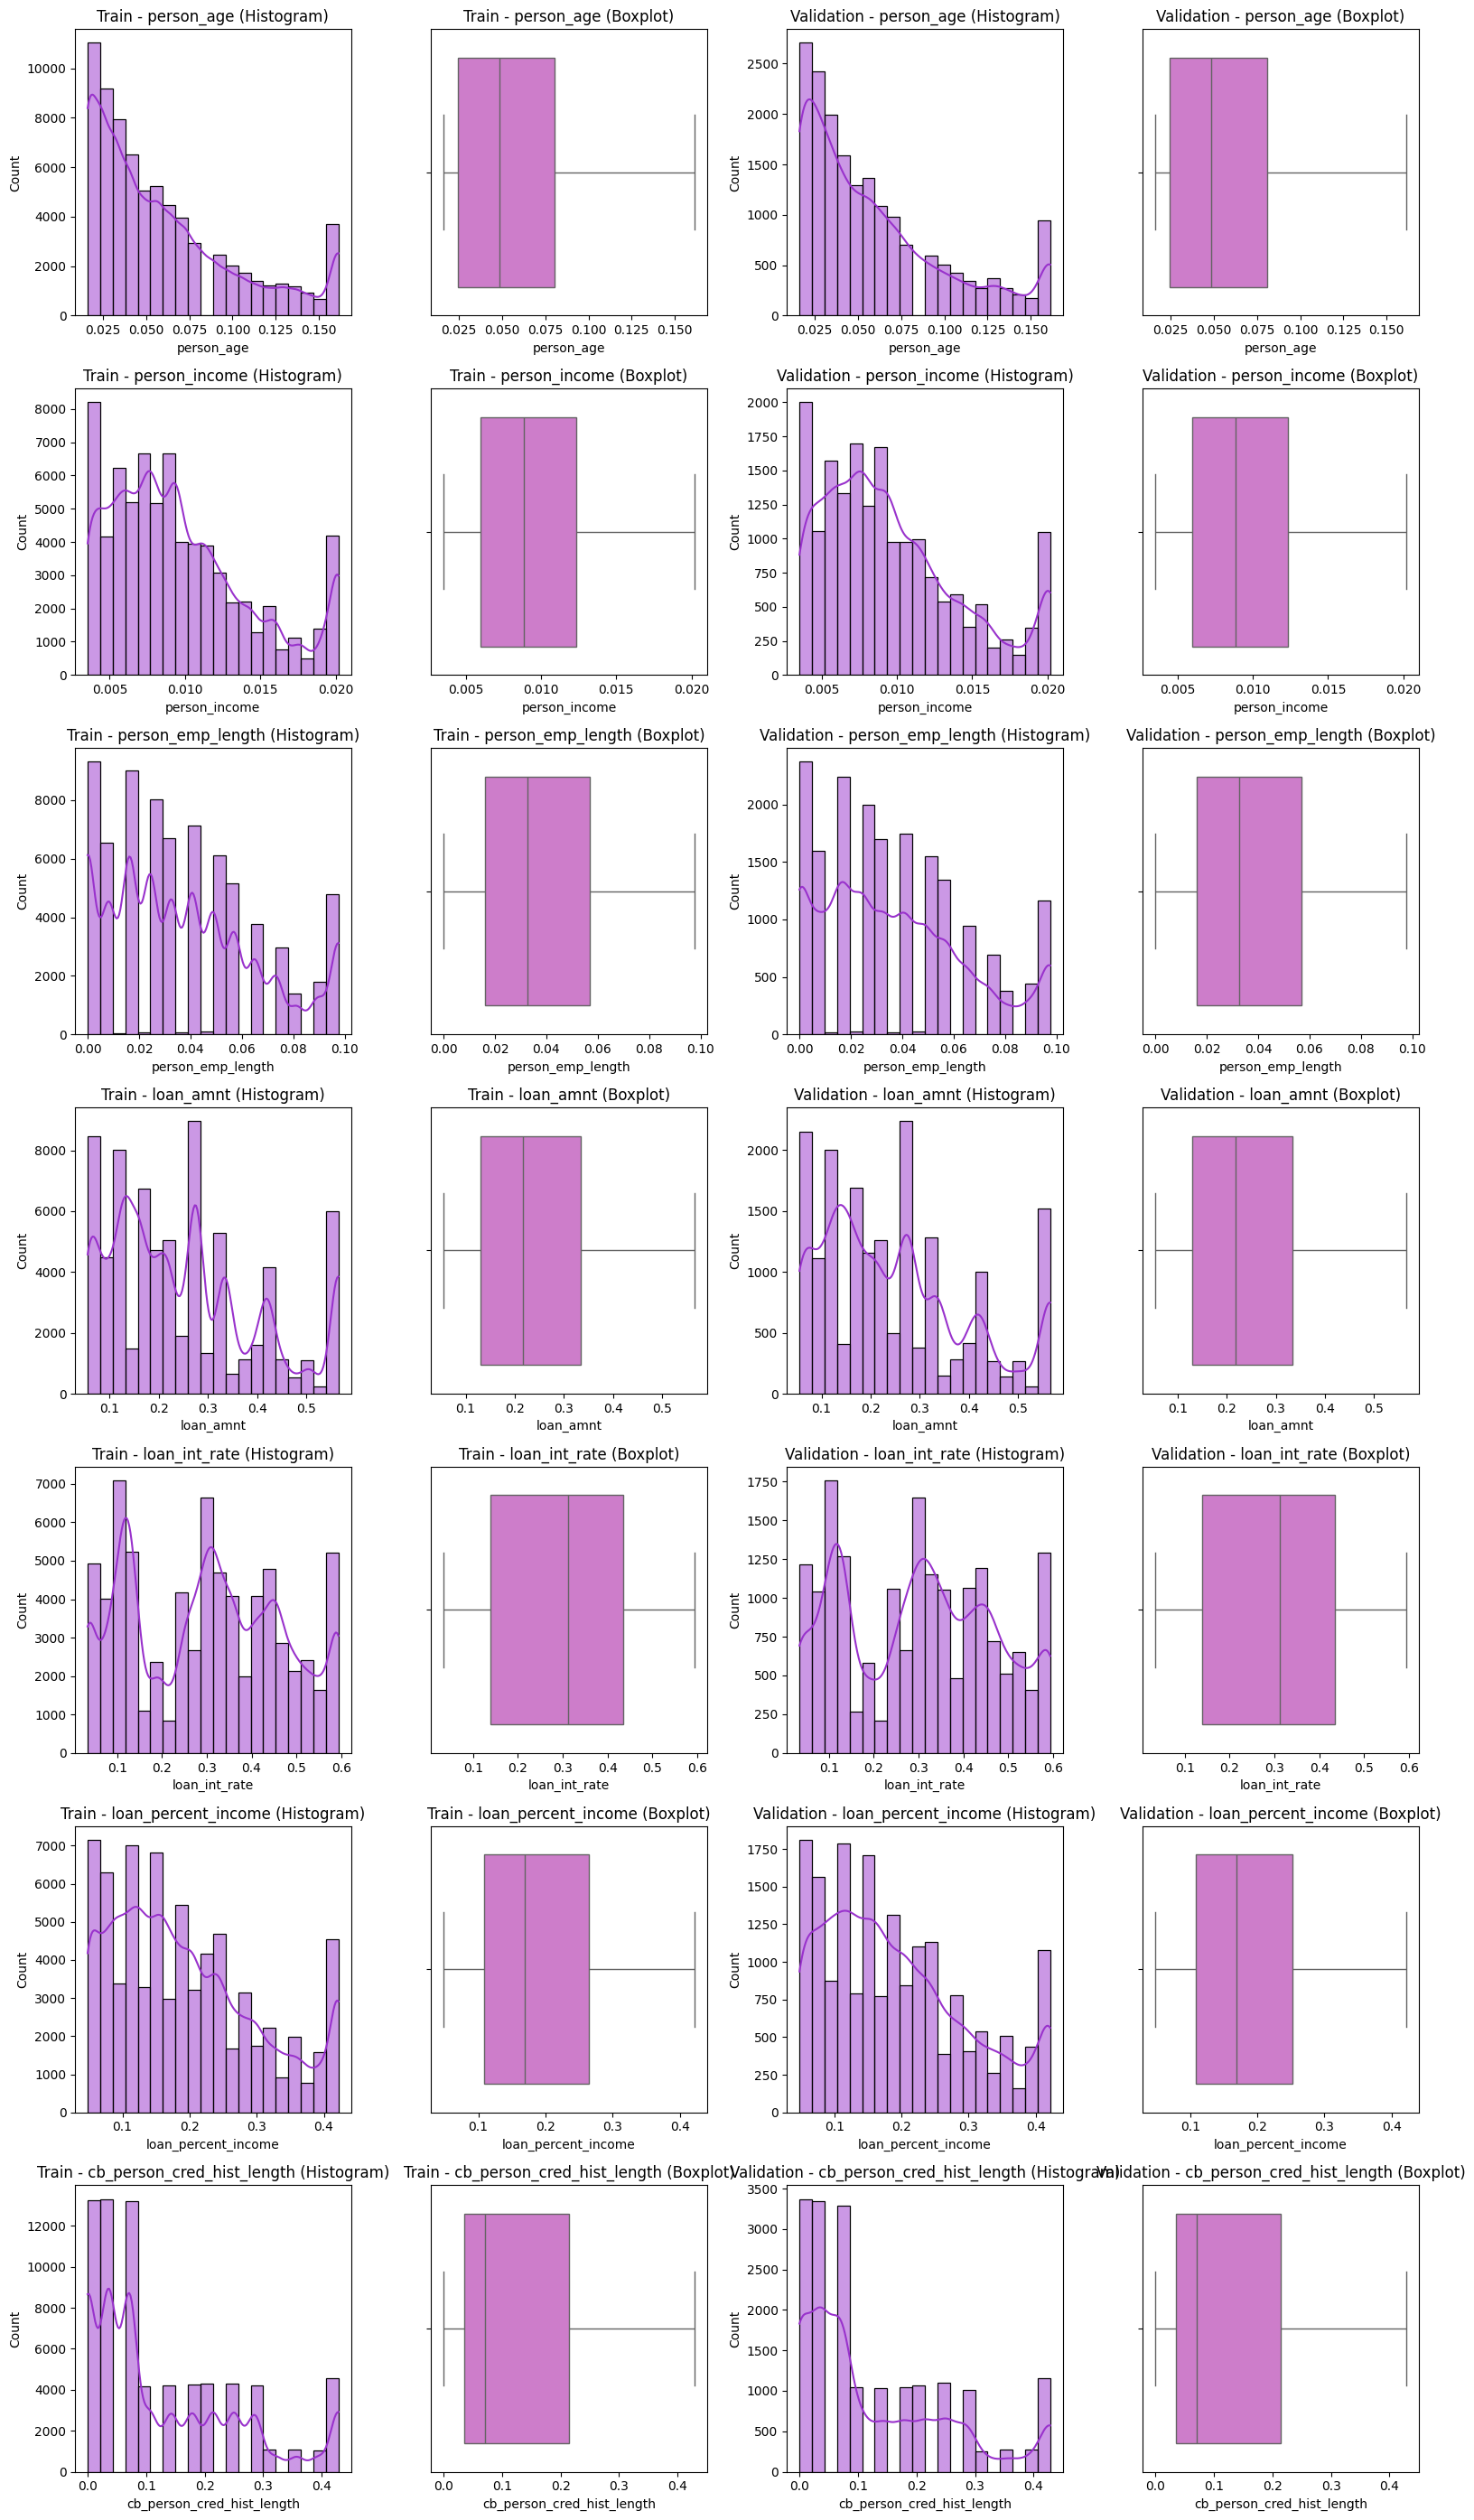

In [ ]:
# Create subplots: Two plots (hist + box) per column for both Train and Validation
fig, axes = plt.subplots(len(plotted_columns), 4, figsize=(16, len(plotted_columns) * 4))

for i, col in enumerate(plotted_columns):
    # Train Data (Left 2 Columns)
    plot_numerical_distribution(col, X_train, axes=axes[i, :2])
    axes[i, 0].set_title(f"Train - {col} (Histogram)")
    axes[i, 1].set_title(f"Train - {col} (Boxplot)")

    # Validation Data (Right 2 Columns)
    plot_numerical_distribution(col, X_val, axes=axes[i, 2:])
    axes[i, 2].set_title(f"Validation - {col} (Histogram)")
    axes[i, 3].set_title(f"Validation - {col} (Boxplot)")

plt.tight_layout()
plt.show()

### 5.3 Encoding

In [ ]:
# Apply Label Encoding to 'loan_grade' and 'cb_person_default_on_file'
label_encoder = LabelEncoder()

# Label Encode 'loan_grade' for X_train and X_val
X_train['loan_grade'] = label_encoder.fit_transform(X_train['loan_grade'])
X_val['loan_grade'] = label_encoder.transform(X_val['loan_grade'])

# Label Encode 'cb_person_default_on_file' for X_train and X_val
X_train['cb_person_default_on_file'] = label_encoder.fit_transform(X_train['cb_person_default_on_file'])
X_val['cb_person_default_on_file'] = label_encoder.transform(X_val['cb_person_default_on_file'])

# Apply One-Hot Encoding to 'person_home_ownership' and 'loan_intent' for X_train and X_val
X_train = pd.get_dummies(X_train, columns=['person_home_ownership', 'loan_intent'])
X_val = pd.get_dummies(X_val, columns=['person_home_ownership', 'loan_intent'])


In [ ]:
# Convert boolean columns to float after get_dummies (if applicable)
for col in X_train.columns:
    if X_train[col].dtype == bool:  # Only apply if column is of boolean type
        X_train[col] = X_train[col].astype(float)
        X_val[col] = X_val[col].astype(float)
display(X_train.head())
display(X_val.head())

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,original,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
12909,0.072581,0.014943,0.008130,0,0.159420,0.138202,0.072289,0,0.285714,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
64185,0.024194,0.006838,0.008130,1,0.275362,0.381461,0.265060,0,0.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
43828,0.072581,0.007672,0.008130,2,0.333333,0.453371,0.289157,1,0.142857,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
79080,0.112903,0.003536,0.097561,1,0.123188,0.360112,0.301205,0,0.285714,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
18010,0.024194,0.007338,0.016260,1,0.246377,0.257303,0.228916,0,0.071429,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,original,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
278,0.112903,0.013509,0.097561,1,0.565217,0.293820,0.289157,0,0.285714,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
51273,0.016129,0.007005,0.024390,3,0.124638,0.593820,0.120482,1,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
41489,0.064516,0.012375,0.024390,1,0.565217,0.292135,0.337349,0,0.214286,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
81144,0.096774,0.008506,0.032520,4,0.427536,0.593820,0.337349,1,0.142857,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
59523,0.016129,0.003536,0.006321,2,0.055072,0.450000,0.120482,0,0.071429,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
X_train.shape,X_val.shape

((72980, 20), (18246, 20))

### 5.4 Features Creation

In [ ]:
def custom_scoring(estimator, X, y):
    """
    Custom scoring function to calculate ROC AUC score using predicted probabilities.
    """
    y_pred = estimator.predict_proba(X)[:, 1]
    return roc_auc_score(y, y_pred)

def better_features(X_train, y_train, X_val, y_val, cols):
    """
    Generate new features by combining columns from X_train using mathematical operations,
    and evaluate them using cross-validation with a custom scoring function (ROC AUC).
    """
    new_cols = []  # List to store new columns
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Stratified K-Fold Cross-Validation

    # Iterate through all possible pairs of columns in `cols`
    for i in tqdm(range(len(cols)), desc='Generating Columns'):
        col1 = cols[i]
        temp_df = pd.DataFrame()  # Temporary dataframe to store generated columns
        temp_df_val = pd.DataFrame()  # Temporary dataframe for validation data

        # Generate combinations of columns and create new features
        for j in range(i + 1, len(cols)):
            col2 = cols[j]

            # Multiply
            temp_df[col1 + '*' + col2] = X_train[col1] * X_train[col2]
            temp_df_val[col1 + '*' + col2] = X_val[col1] * X_val[col2]

            # Divide (col1 / col2)
            temp_df[col1 + '/' + col2] = X_train[col1] / (X_train[col2] + 1e-5)
            temp_df_val[col1 + '/' + col2] = X_val[col1] / (X_val[col2] + 1e-5)

            # Divide (col2 / col1)
            temp_df[col2 + '/' + col1] = X_train[col2] / (X_train[col1] + 1e-5)
            temp_df_val[col2 + '/' + col1] = X_val[col2] / (X_val[col1] + 1e-5)

            # Subtract
            temp_df[col1 + '-' + col2] = X_train[col1] - X_train[col2]
            temp_df_val[col1 + '-' + col2] = X_val[col1] - X_val[col2]

            # Add
            temp_df[col1 + '+' + col2] = X_train[col1] + X_train[col2]
            temp_df_val[col1 + '+' + col2] = X_val[col1] + X_val[col2]

        # Model pipeline: StandardScaler followed by LogisticRegression
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('logistic_regression', LogisticRegression())
        ])

        SCORES = []  # List to store the scores of each new column

        # Evaluate each generated column using cross-validation
        for column in temp_df.columns:
            X_temp = temp_df[column].values.reshape(-1, 1)  # Reshape to fit the model
            y_temp = y_train  # Use y_train as target variable
            scores = cross_val_score(model, X_temp, y_temp, cv=skf, scoring=custom_scoring)
            mean_score = np.mean(scores)  # Calculate mean AUC score
            SCORES.append((column, mean_score))

        # If there are valid scores, find the best column based on the AUC score
        if SCORES:
            best_col, best_score = sorted(SCORES, key=lambda x: x[1], reverse=True)[0]

            # Check for correlation with other columns to avoid multicollinearity
            corr_with_other_cols = X_train.drop(new_cols, axis=1).corrwith(temp_df[best_col])
            if (corr_with_other_cols.abs().max() < 0.9 or best_score > best_score) and corr_with_other_cols.abs().max() != 1:
                # Add the new feature to the training and validation sets
                X_train[best_col] = temp_df[best_col]
                X_val[best_col] = temp_df_val[best_col]
                new_cols.append(best_col)
                print(f"Added column '{best_col}' with AUC Score: {best_score:.4f} & Correlation {corr_with_other_cols.abs().max():.4f}")

    return X_train, X_val, new_cols


In [ ]:
selected_cols=[f for f in X_train.columns if X_train[f].nunique()>2]# select continuous columns to save runtime
X_train, X_val, new_cols = better_features(X_train, y_train, X_val, y_val, selected_cols)

Generating Columns:  25%|██▌       | 2/8 [00:15<00:48,  8.01s/it]

Added column 'person_income/loan_grade' with AUC Score: 0.7922 & Correlation 0.7298


Generating Columns:  62%|██████▎   | 5/8 [00:30<00:15,  5.30s/it]

Added column 'loan_amnt+loan_int_rate' with AUC Score: 0.7357 & Correlation 0.7808


Generating Columns:  75%|███████▌  | 6/8 [00:32<00:08,  4.22s/it]

Added column 'loan_int_rate+loan_percent_income' with AUC Score: 0.8300 & Correlation 0.8650


Generating Columns: 100%|██████████| 8/8 [00:33<00:00,  4.22s/it]

Added column 'loan_percent_income-cb_person_cred_hist_length' with AUC Score: 0.6789 & Correlation 0.7734


In [ ]:
# new_cols=['person_income/loan_grade',
#  'loan_amnt+loan_int_rate',
#  'loan_int_rate+loan_percent_income',
#  'loan_percent_income-cb_person_cred_hist_length',
# ]

In [ ]:
display(X_train.head())
display(X_val.head())

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,original,...,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_income/loan_grade,loan_amnt+loan_int_rate,loan_int_rate+loan_percent_income,loan_percent_income-cb_person_cred_hist_length
12909,0.072581,0.014943,0.008130,0,0.159420,0.138202,0.072289,0,0.285714,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1494.329553,0.297623,0.210491,-0.213425
64185,0.024194,0.006838,0.008130,1,0.275362,0.381461,0.265060,0,0.000000,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.006838,0.656823,0.646521,0.265060
43828,0.072581,0.007672,0.008130,2,0.333333,0.453371,0.289157,1,0.142857,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.003836,0.786704,0.742527,0.146299
79080,0.112903,0.003536,0.097561,1,0.123188,0.360112,0.301205,0,0.285714,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.003536,0.483301,0.661317,0.015491
18010,0.024194,0.007338,0.016260,1,0.246377,0.257303,0.228916,0,0.071429,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.007338,0.503680,0.486219,0.157487


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,original,...,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_income/loan_grade,loan_amnt+loan_int_rate,loan_int_rate+loan_percent_income,loan_percent_income-cb_person_cred_hist_length
278,0.112903,0.013509,0.097561,1,0.565217,0.293820,0.289157,0,0.285714,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.013509,0.859038,0.582977,0.003442
51273,0.016129,0.007005,0.024390,3,0.124638,0.593820,0.120482,1,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.002335,0.718458,0.714302,0.120482
41489,0.064516,0.012375,0.024390,1,0.565217,0.292135,0.337349,0,0.214286,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.012375,0.857352,0.629484,0.123064
81144,0.096774,0.008506,0.032520,4,0.427536,0.593820,0.337349,1,0.142857,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.002126,1.021356,0.931170,0.194492
59523,0.016129,0.003536,0.006321,2,0.055072,0.450000,0.120482,0,0.071429,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.001768,0.505072,0.570482,0.049053


## 7. Probability of Default Modelling

In [ ]:
def evaluate_model(y_pred_probs: np.ndarray, y_val: np.ndarray, threshold: float = 0.5,
                   plot_roc_curve: bool = True, plot_conf_matrix: bool = True) -> Dict[str, float]:
    """
    Evaluates a machine learning model on validation data.

    Parameters:
    - y_pred_probs: Predicted probabilities for the positive class (binary classification).
    - y_val: True labels for validation.
    - threshold: Threshold for binary classification (default 0.5).
    - plot_roc_curve: Boolean to plot ROC curve (default True).
    - plot_conf_matrix: Boolean to plot confusion matrix (default True).

    Returns:
    - metrics: Dictionary containing 'accuracy', 'precision', 'recall', 'f1', 'roc_auc' scores.
    """
    # Get binary predictions based on the threshold
    y_pred = (y_pred_probs > threshold).astype(int)   # converting to binary predictions

    # Calculate evaluation metrics
    report = classification_report(y_val, y_pred, output_dict=True)
    accuracy: float = report['accuracy']

    # Precision and recall for the positive class (class 1)
    precision: float = report['1']['precision']
    recall: float = report['1']['recall']
    f1: float = report['1']['f1-score']

    # Calculate AUC
    roc_auc: float = roc_auc_score(y_val, y_pred_probs)

    metrics: Dict[str, float] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    }

    # Print classification report
    print("Classification Report:")
    print(classification_report(y_val, y_pred))

    # Plot confusion matrix
    if plot_conf_matrix:
        cm = confusion_matrix(y_val, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Approved', 'Approved'], yticklabels=['Not Approved', 'Approved'])
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.title('Confusion Matrix')
        plt.show()

    # Plot ROC curve
    if plot_roc_curve:
        fpr, tpr, thresholds = roc_curve(y_val, y_pred_probs)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='blue', label='ROC curve (AUC = %0.2f)' % roc_auc)
        plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc='lower right')
        plt.show()

    return metrics




def plot_importances(model, X_train, X_val, y_val, n_repeats=5):
    """
    Plots Feature Importances and Permutation Importances for a trained model.

    Parameters:
    - model: The trained machine learning model (e.g., Random Forest).
    - X_train: Training features.
    - X_val: Validation features.
    - y_val: Validation labels.
    - n_repeats: Number of repeats for permutation importance (default 5).
    """
    # Feature Importances (from model)
    importances = model.feature_importances_  # Get feature importances from the trained model
    features = X_train.columns  # Get feature names

    # Sort feature importances
    indices = np.argsort(importances)[::-1]

    # Plot Feature Importances
    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances[indices], y=features[indices], orient='h')
    plt.title("Feature Importances from Model")
    plt.xlabel("Importance Score")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

    # Permutation Importance (using model and validation data)
    result = permutation_importance(
        model,
        X_val,
        y_val,
        n_repeats=n_repeats,
        random_state=42
    )

    # Sort permutation importances
    sorted_idx = result.importances_mean.argsort()

    # Plot Permutation Importances
    plt.figure(figsize=(8, 6))
    plt.barh(X_val.columns[sorted_idx], result.importances_mean[sorted_idx])
    plt.xlabel("Permutation Importance (mean)")
    plt.title("Permutation Importances")
    plt.tight_layout()
    plt.show()


### 7.1 Logistic Regression

In [ ]:
# lr1_model = LogisticRegression(solver='liblinear',max_iter = 1000)  # Adjust solver or parameters if needed

# # Train the model
# lr1_model.fit(X_train, y_train)

# # Predict probabilities on the validation set
# y_pred_probs_lr1 = lr1_model.predict_proba(X_val)[:, 1]  # Get the probabilities for the positive class

In [ ]:
# # Use the evaluate_model function to report the results
# metrics_lr1 = evaluate_model(y_pred_probs_lr1, y_val)

### 7.2 LightGBM

**LightGBM (Light Gradient Boosting Machine)** is based on gradient boosting trees. It can quickly train models on large datasets and improve processing speed without sacrificing accuracy.
1.   **Gradient Boosting Decision Tree (GBDT)** is a boosting method
based on additive models and forward stepwise algorithms. GBDT optimizes the objective function by iterating multiple trees, where each tree fits the residuals or negative gradients of the previous model.
2.   **Improvements of LightGBM**:


*   *Leaf-wise Growth Strategy:* Unlike the traditional level-wise growth
method, LightGBM adopts leaf-wise growth, where in each iteration, the node with the highest gain among all leaf nodes is selected for splitting, resulting in an asymmetric tree structure.
*   *Histogram-based Algorithm:* Continuous features are discretized into a limited number of histograms, speeding up computation and reducing memory usage.
*   *Gradient-based One-Side Sampling (GOSS):* Retains samples with large gradients while randomly sampling those with smaller gradients to accelerate model training.
*   *Exclusive Feature Bundling (EFB):* Bundles sparse features together to further reduce feature dimensions.

In [ ]:
# # Initialize the LightGBM model
# lgbm_model = LGBMClassifier(n_estimators=1000, learning_rate=0.01, scale_pos_weight=6, verbose=-1,random_state=42)

**parameters:**


*   **n_estimators**: the number of trees. A higher number can improve model performance but also increases training time and the risk of overfitting.
*   **learning_rate**: This controls the contribution of each tree to the final model. A lower learning rate usually leads to better performance but requires more boosting rounds.


*   **scale_pos_weight**: Weight for positive samples (the ratio of the number of negative samples to positive samples). This parameter is to handle class imbalance.
*   **verbose**: Verbosity level. -1 means do not output detailed information during the training process.





In [ ]:
# scoring_metrics = ['accuracy', 'roc_auc', 'f1', 'precision', 'recall']
# lgbm_scores = cross_validate(lgbm_model, X_train, y_train, cv=5, scoring=scoring_metrics, return_train_score=True)

# for metric in scoring_metrics:
#     print(f"LightGBM Cross-Validation {metric.capitalize()} Scores: {lgbm_scores['test_' + metric]}")
#     print(f"Mean {metric.capitalize()} Score: {np.mean(lgbm_scores['test_' + metric])}")



*   **Accuracy**: The ratio of correctly predicted instances to the total instances. It measures the overall correctness of the model.
*   **ROC AUC**: The area under the Receiver Operating Characteristic curve. It measures the model's ability to distinguish between classes. A higher value indicates better performance.
*   **F1 Score**: The harmonic mean of precision and recall. It balances the trade-off between precision and recall, especially useful for imbalanced datasets.
*   **Precision**: The ratio of true positive predictions to the total positive predictions. It measures the accuracy of positive predictions
*   **Recall**: The ratio of true positive predictions to the total actual positives. It measures the model's ability to identify all relevant instances.






In [ ]:
# lgbm_model.fit(X_train, y_train)
# y_pred_probs_lgbm = lgbm_model.predict_proba(X_val)[:, 1]
# y_pred_lgbm = (y_pred_probs_lgbm > 0.5).astype(int)

In [ ]:
# metrics_lgbm = evaluate_model(y_pred_probs_lgbm, y_val)

Overall, the LightGBM model performs well across various metrics.

It has good balanced performance when handling imbalanced datasets.

### 7.4 Random Forest

Random Forest is an ensemble learning method that constructs multiple decision trees and combines their outputs (by voting for classification or averaging for regression). It leverages two key ideas: bootstrapping (sampling with replacement) to generate multiple training subsets and random feature selection at each split. This diversity among trees helps reduce overfitting and improves generalization.

In [ ]:
# rf_model = RandomForestClassifier(
#     n_estimators=100,
#     max_depth=None,
#     random_state=42,
#     n_jobs=-1
# )

# rf_model.fit(X_train, y_train)
# y_pred_probs_rf = rf_model.predict(X_val)

In [ ]:
# metrics_rf = evaluate_model(y_pred_probs_rf, y_val)

### 7.5 XGBOOST

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     15196
           1       0.96      0.69      0.80      3050

    accuracy                           0.94     18246
   macro avg       0.95      0.84      0.89     18246
weighted avg       0.94      0.94      0.94     18246



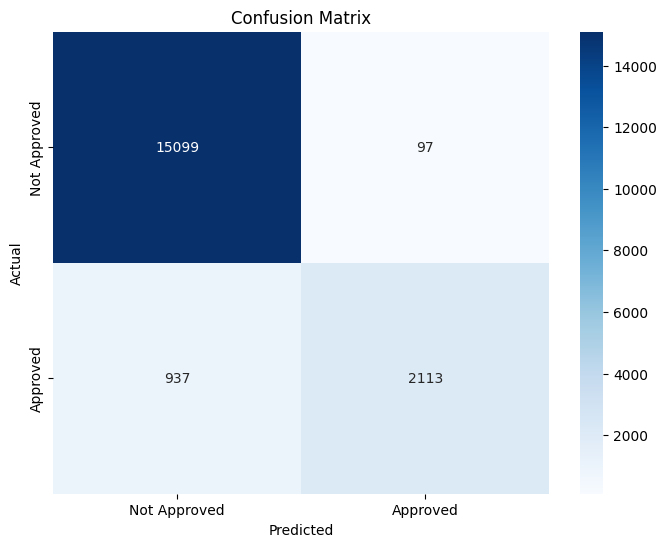

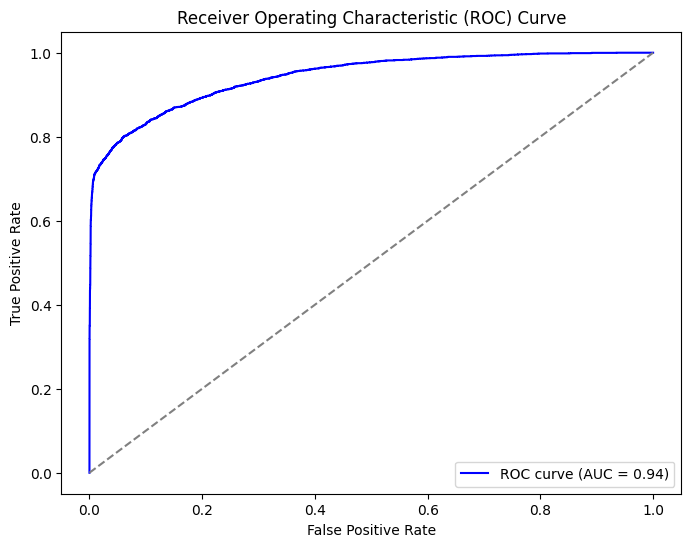

In [ ]:
xgb_model = XGBClassifier(max_depth=8,n_estimators=200,min_child_weight=8, subsample=0.8, learning_rate =0.02,seed=69)

xgb_model.fit(X_train, y_train)

# Predict the probability of each sample belonging to the positive class
y_pred_probs_xgb = xgb_model.predict_proba(X_val)[:, 1]

metrics_xgb = evaluate_model(y_pred_probs_xgb, y_val)

### 7.6 Model Comparison

In [ ]:
# # Define models in the correct order (original before PCA versions)
# models = {
#     "Logistic Regression": metrics_lr1,
#     "LGBM": metrics_lgbm,
#     "Random Forest": metrics_rf,
#     "XGBoost": metrics_xgb
#     # ,"Neural Network": metrics_nn
# }

# # Create a PrettyTable
# table = PrettyTable()
# table.field_names = ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]

# # Populate the table
# for model_name, metrics in models.items():
#     table.add_row([
#         model_name,
#         round(metrics["accuracy"], 4),
#         round(metrics["precision"], 4),
#         round(metrics["recall"], 4),
#         round(metrics["f1"], 4),
#         round(metrics["roc_auc"], 4)
#     ])

# # Print the table
# print(table)


In selecting the best classifier for predicting loan default probabilities which is crucial for the modelling of expected loss in the next step, we consider the following criteria:  

1. **High ROC AUC Score**  
   - ROC AUC measures the model's ability to distinguish between defaulters and non-defaulters.  
   - XGBoost achieves **0.9436**, which is among the highest, ensuring reliable probability estimates.  

2. **Balanced Precision and Recall**  
   - Precision is crucial to avoid false positives (incorrectly labeling a loan as risky).  
   - Recall is important to capture actual defaulters.  
   - XGBoost has **Precision: 0.9557, Recall: 0.6938**, leading to a well-balanced **F1-score of 0.804**.  

3. **Better Handling of Imbalanced Data**  
   - XGBoost is known for its robustness in handling class imbalance through its built-in regularization and boosting techniques.  

4. **Consistency Across Metrics**  
   - While LightGBM has a slightly higher recall (**0.8433**), its precision is significantly lower (**0.6661**), leading to a lower F1-score (**0.7443**).  
   - XGBoost provides a more stable balance between all key metrics.  


## 8. Expected Losses Modelling

expected losses = Probability of Default * Loan Amount

### 8.0 Train & Test Split for Expected Losses Modelling

In [ ]:
print("Train Copy shape:", train_copy.shape)
print("Original Dataset Copy shape:", original_copy.shape)

Train Copy shape: (58645, 14)
Original Dataset Copy shape: (32581, 13)


In [ ]:
train_copy.drop(columns=["id"],inplace=True)
print("Train Copy shape:", train_copy.shape)
print("Original Dataset Copy shape:", original_copy.shape)

Train Copy shape: (58645, 13)
Original Dataset Copy shape: (32581, 13)


In [ ]:
train_data_regress = pd.concat([train_copy, original_copy], axis=0).reset_index(drop=True)
print("Train dataset for expected losses shape:", train_data_regress.shape)

Train dataset for expected losses shape: (91226, 13)


In [ ]:
X = train_data_regress.drop(columns=['loan_status'])
y = train_data_regress['loan_status']
# Split the data into training and validation sets
X_train_regress, X_val_regress, y_train_regress, y_val_regress = train_test_split(X, y, test_size=0.2, random_state=42)
# Display the shapes of the training and validation sets
X_train_regress.shape, X_val_regress.shape, y_train_regress.shape, y_val_regress.shape

((72980, 12), (18246, 12), (72980,), (18246,))

In [ ]:
# Get the predicted probabilities for the training and validation sets
train_probs_approval = xgb_model.predict_proba(X_train)[:, 1]  # Probability of approval (class 1)
val_probs_approval = xgb_model.predict_proba(X_val)[:, 1]  # Probability of approval (class 1)

# Calculate the probability of default (1 - probability of approval)
train_probs_default = 1 - train_probs_approval
val_probs_default = 1 - val_probs_approval

In [ ]:
# Add the predicted probabilities of default as new columns to the respective datasets
X_train_regress['default_prob'] = train_probs_default
X_val_regress['default_prob'] = val_probs_default

In [ ]:
# Update the target variable to be the expected loss
X_train_regress['expected_loss'] = X_train_regress['default_prob'] * X_train_regress['loan_amnt']
X_val_regress['expected_loss'] = X_val_regress['default_prob'] * X_val_regress['loan_amnt']

# Use expected_loss as the new target variable
y_train_regress = X_train_regress['expected_loss'].values
y_val_regress = X_val_regress['expected_loss'].values

# Drop 'default_prob', 'loan_amnt', and 'expected_loss' before training
X_train_regress = X_train_regress.drop(columns=['default_prob', 'loan_amnt', 'expected_loss'])
X_val_regress = X_val_regress.drop(columns=['default_prob', 'loan_amnt', 'expected_loss'])

# Ensure that the shapes match after dropping the columns
X_train_regress.shape, X_val_regress.shape, y_train_regress.shape, y_val_regress.shape

((72980, 11), (18246, 11), (72980,), (18246,))

### 8.1 EDA & Data Cleaning

*Refer to 5.2 for transforamtion function*

In [ ]:
def evaluate_transformations_regression(df: pd.DataFrame, features: List[str], target: str) -> List[Tuple[str, float]]:
    """
    Evaluate transformations using XGBRegressor and MAE
    """
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    mae_scores = []
    for feature in features:
        X, y = df[[feature]].values, df[target].values
        mae_list = []
        for train_idx, val_idx in kf.split(X):
            model = XGBRegressor()
            model.fit(X[train_idx], y[train_idx])
            y_pred = model.predict(X[val_idx])
            mae_list.append(mean_absolute_error(y[val_idx], y_pred))
        mae_scores.append((feature, np.mean(mae_list)))
    return mae_scores


def transformer_regression(
    df: pd.DataFrame, features: List[str], target: str, save_path: str
) -> Tuple[pd.DataFrame, Dict[str, str], float, str]:
    """
    Apply transformations and evaluate performance.
    If the best transformation is not the original feature, replace the original feature with the best transformation.
    """
    # Create a copy of the original DataFrame to avoid modifying the input df
    df_copy = df.copy()

    best_features = {}
    overall_best_score = np.inf
    overall_best_feature = ''
    table = PrettyTable()
    table.field_names = ['Feature', 'Original MAE', 'Best Transformation', 'Best MAE']

    # Scale the features
    scaler = MinMaxScaler()
    df_copy[features] = scaler.fit_transform(df_copy[features])
    joblib.dump(scaler, save_path + 'scaler.joblib')

    for feature in features:
        # Apply transformations on the copied DataFrame
        df_transformed = df_copy.copy()  # Copy to avoid modifying df_copy

        df_transformed = log_transformation(df_transformed, feature)
        df_transformed = sqrt_transformation(df_transformed, feature)
        df_transformed = box_cox_transformation(df_transformed, feature, save_path)
        df_transformed = power_transformation(df_transformed, feature, 0.25, save_path)
        df_transformed = power_transformation(df_transformed, feature, 2, save_path)

        transformations = [feature, f'log_{feature}', f'sqrt_{feature}', f'bx_cx_{feature}', f'pow0.25_{feature}', f'pow2_{feature}']
        scores = evaluate_transformations_regression(df_transformed, transformations, target)

        # Find the best transformation
        best_feature, best_score = min(scores, key=lambda x: x[1])

        # Store the best transformation for each feature
        best_features[feature] = best_feature

        # Update overall best transformation
        if best_score < overall_best_score:
            overall_best_score = best_score
            overall_best_feature = best_feature

        # Get original feature's MAE
        original_mae = next(score for f, score in scores if f == feature)
        table.add_row([feature, original_mae, best_feature, best_score])

        # Apply best transformation to the copied DataFrame (without modifying the original df)
        if best_feature != feature:
            df_copy[feature] = df_transformed[best_feature]

    print(table)
    print(f"Best Feature: {overall_best_feature} with MAE: {overall_best_score}")

    return df_copy, best_features, overall_best_score, overall_best_feature


def transformer_target_regression(
    df: pd.DataFrame, features: List[str], target: str, save_path: str
) -> Tuple[pd.DataFrame, str, float]:
    """
    Apply transformations to the target variable, evaluate performance using regression,
    and replace the target column with the best transformation.
    """
    # Create a copy of the original DataFrame to avoid modifying the input df
    df_copy = df.copy()

    best_target_transformation = ''
    overall_best_score = np.inf
    table = PrettyTable()
    table.field_names = ['Transformation', 'MAE']

    # Extract the target column for transformation
    target_values = df_copy[target]

    # Apply transformations to the target variable
    df_transformed = df_copy.copy()  # Copy to avoid modifying df_copy
    df_transformed = log_transformation(df_transformed, target)
    df_transformed = sqrt_transformation(df_transformed, target)
    df_transformed = box_cox_transformation(df_transformed, target, save_path)
    df_transformed = power_transformation(df_transformed, target, 0.25, save_path)
    df_transformed = power_transformation(df_transformed, target, 2, save_path)

    # List of target transformations
    transformations = [target, f'log_{target}', f'sqrt_{target}', f'bx_cx_{target}', f'pow0.25_{target}', f'pow2_{target}']

    # Initialize a regressor (e.g., XGBRegressor)
    regressor = XGBRegressor(objective='reg:squarederror', n_estimators=100)

    # Loop over the transformations and evaluate performance
    for transformed_target in transformations:
        # Use transformed target for regression
        X = df_transformed[features]  # Features from the DataFrame
        y = df_transformed[transformed_target]  # Transformed target values

        # Fit the regressor
        regressor.fit(X, y)

        # Predict and calculate MAE
        y_pred = regressor.predict(X)
        mae = mean_absolute_error(y, y_pred)

        # Add the MAE for this transformation to the table
        table.add_row([transformed_target, mae])

        # Store the best transformation if the current MAE is better
        if mae < overall_best_score:
            overall_best_score = mae
            best_target_transformation = transformed_target

    print(table)
    print(f"Best Target Transformation: {best_target_transformation} with MAE: {overall_best_score}")

    # Apply the best transformation to the target column if it's not the original target
    if best_target_transformation != target:
        df_copy[target] = df_transformed[best_target_transformation]

    return df_copy, best_target_transformation, overall_best_score


#### 8.1.1 Fixing Data Types

In [ ]:
X_train_regress.dtypes

,0
person_age,int64
person_income,int64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_int_rate,float64
loan_percent_income,float64
cb_person_default_on_file,object
cb_person_cred_hist_length,int64


In [ ]:
# Convert numerical columns to float64
numerical_columns_no_target = [n for n in numerical_columns_no_target if n != 'loan_amnt']
X_train_regress[numerical_columns_no_target] = X_train_regress[numerical_columns_no_target].astype('float64')
X_val_regress[numerical_columns_no_target] = X_val_regress[numerical_columns_no_target].astype('float64')

#### 8.1.2 Missing & Duplicated Values

In [ ]:
# Train Dataset
print(f'Train regression Missing values: {X_train_regress.isna().sum().sum()}')
print(f'Train regression Duplicated values: {X_train_regress.duplicated().sum()}')

# Validation Dataset
print(f'Validation regression Missing values: {X_val_regress.isna().sum().sum()}')
print(f'Validation regression Duplicated values: {X_val_regress.duplicated().sum()}')

Train regression Missing values: 3187
Train regression Duplicated values: 108
Validation regression Missing values: 824
Validation regression Duplicated values: 6


*Remarks: Duplicated values are dropped. Nevertheless, aggregation of duplicated record could be applied in the future (remove duplicaed record in X and take the average of duplicated records' y as target)*

In [ ]:
# For the training set:
mask_train = ~X_train_regress.duplicated()  # Create a boolean mask for non-duplicated rows
X_train_regress = X_train_regress[mask_train]  # Keep only non-duplicate rows
y_train_regress = y_train_regress[mask_train]    # Align y with the non-duplicate rows

# For the validation set:
mask_val = ~X_val_regress.duplicated()  # Create a boolean mask for non-duplicated rows
X_val_regress = X_val_regress[mask_val]   # Keep only non-duplicate rows
y_val_regress = y_val_regress[mask_val]     # Align y with the non-duplicate rows

# Display new shapes to verify
print("X_train_regress shape after dropping duplicates:", X_train_regress.shape)
print("y_train_regress shape after dropping duplicates:", y_train_regress.shape)
print("X_val_regress shape after dropping duplicates:", X_val_regress.shape)
print("y_val_regress shape after dropping duplicates:", y_val_regress.shape)

X_train_regress shape after dropping duplicates: (72872, 11)
y_train_regress shape after dropping duplicates: (72872,)
X_val_regress shape after dropping duplicates: (18240, 11)
y_val_regress shape after dropping duplicates: (18240,)


*Remarks: The imputation of missing values are similar to section 5.1*

Iterations:   0%|          | 0/5 [00:00<?, ?it/s]Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Iterations:  20%|██        | 1/5 [00:11<00:46, 11.64s/it]Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Iterations:  40%|████      | 2/5 [00:24<00:37, 12.60s/it]Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Iterations:  60%|██████    | 3/5 [00:38<00:25, 12.95s/it]Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Iterations:  80%|████████  | 4/5 [00:55<00:14, 14.52s/it]Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Iterations: 100%|██████

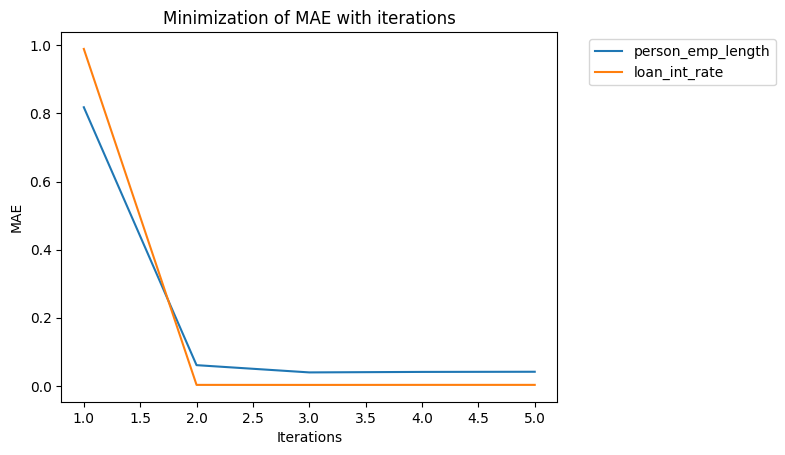

CPU times: user 1min 11s, sys: 38 s, total: 1min 49s
Wall time: 1min 13s


In [ ]:
%%time
X_regress_combined = pd.concat([X_train_regress, X_val_regress], axis=0)
train_len = X_train_regress.shape[0]
X_regress_imputed = fill_missing_numerical(X_regress_combined, max_iterations=5)

In [ ]:
X_train_regress = X_regress_imputed.iloc[:train_len, :].copy()
X_val_regress = X_regress_imputed.iloc[train_len:, :].copy()

# Train Dataset
print(f'Train regression Missing values: {X_train_regress.isna().sum().sum()}')
print(f'Train regression Duplicated values: {X_train_regress.duplicated().sum()}')

# Validation Dataset
print(f'Validation regression Missing values: {X_val_regress.isna().sum().sum()}')
print(f'Validation regression Duplicated values: {X_val_regress.duplicated().sum()}')

Train regression Missing values: 0
Train regression Duplicated values: 0
Validation regression Missing values: 0
Validation regression Duplicated values: 0


#### 8.1.3 Handle Outliers

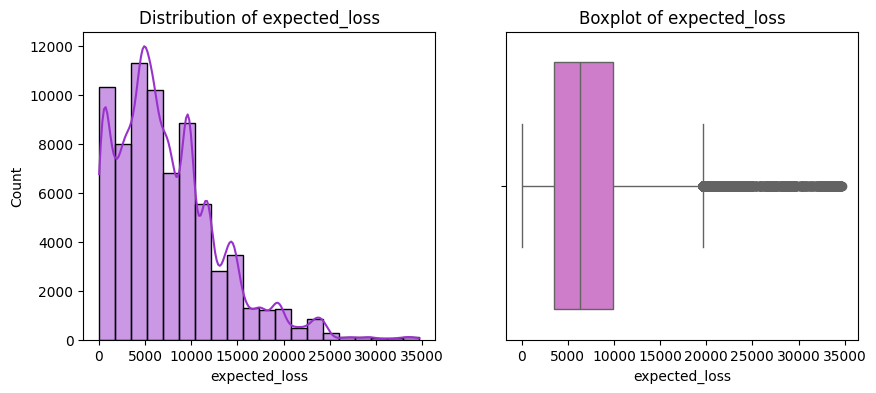

In [ ]:
# Convert the NumPy array to a pandas DataFrame
column_name = "expected_loss"  # Choose a column name
y_train_regress_df = pd.DataFrame(y_train_regress, columns=[column_name])
plot_numerical_distribution(column_name, y_train_regress_df)

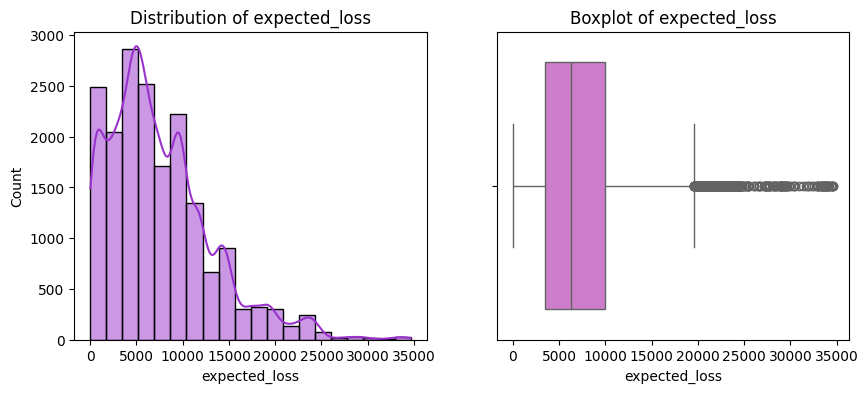

In [ ]:
y_val_regress_df = pd.DataFrame(y_val_regress, columns=[column_name])
plot_numerical_distribution(column_name, y_val_regress_df)

In [ ]:
%%time
target_column_regress = 'expected_loss'
df_regress_imputed = X_regress_imputed.copy()
df_regress_imputed[target_column_regress] = np.concatenate([y_train_regress, y_val_regress], axis=0)
numerical_columns_no_target = [n for n in numerical_columns_no_target if n != 'original']


df_regress_imputed_transformed, best_cols, overall_best_score, overall_best_col = transformer_regression(
    df_regress_imputed, numerical_columns_no_target, target_column_regress, save_path='/content/drive/MyDrive/loan_approval/'
)


+----------------------------+--------------------+----------------------------+--------------------+
|          Feature           |    Original MAE    |    Best Transformation     |      Best MAE      |
+----------------------------+--------------------+----------------------------+--------------------+
|         person_age         | 4292.292313398697  |         person_age         | 4292.292313398697  |
|       person_income        | 3648.066620465915  |   pow0.25_person_income    |  3647.84042190548  |
|     person_emp_length      | 4248.842956509441  |     person_emp_length      | 4248.842956509441  |
|       loan_int_rate        | 4141.616458076355  |       loan_int_rate        | 4141.616458076355  |
|    loan_percent_income     | 3546.3013513383135 |    loan_percent_income     | 3546.3013513383135 |
| cb_person_cred_hist_length | 4304.780281450706  | cb_person_cred_hist_length | 4304.780281450706  |
+----------------------------+--------------------+----------------------------+--

*Remarks: Several transformations will be applied to numerical features before modelling. Besides, all features were scaled using minimax sacler*

In [ ]:
df_regress_imputed_transformed, best_transformation, best_score = transformer_target_regression(
    df_regress_imputed_transformed,
    numerical_columns_no_target,  # Features are all columns except the last one
    target_column_regress,  # Target is the last column
    save_path='/content/drive/MyDrive/loan_approval/'  # Path to save scaler
)


+-----------------------+---------------------+
|     Transformation    |         MAE         |
+-----------------------+---------------------+
|     expected_loss     |  884.1073437352837  |
|   log_expected_loss   |  0.2262969297723633 |
|   sqrt_expected_loss  |  6.262239889572986  |
|  bx_cx_expected_loss  | 0.18995354707669668 |
| pow0.25_expected_loss |  0.4096037245706787 |
|   pow2_expected_loss  |  14424645.215578862 |
+-----------------------+---------------------+
Best Target Transformation: bx_cx_expected_loss with MAE: 0.18995354707669668


*Remarks: Box-Cox transformations will be applied to targets before modelling.*

In [ ]:
X_train_regress = df_regress_imputed_transformed.iloc[:train_len, :-1].copy()
X_val_regress = df_regress_imputed_transformed.iloc[train_len:, :-1].copy()
y_train_regress = df_regress_imputed_transformed.iloc[:train_len, -1].copy().values
y_val_regress = df_regress_imputed_transformed.iloc[train_len:, -1].copy().values
X_train_regress.shape, X_val_regress.shape, y_train_regress.shape, y_val_regress.shape

((72872, 11), (18240, 11), (72872,), (18240,))

In [ ]:
for col in numerical_columns_no_target:
    Q1 = X_train_regress[col].quantile(0.05)
    Q3 = X_train_regress[col].quantile(0.95)
    Q1_val = X_val_regress[col].quantile(0.05)
    Q3_val = X_val_regress[col].quantile(0.95)

    X_train_regress[col] = np.clip(X_train_regress[col], Q1, Q3)
    X_val_regress[col] = np.clip(X_val_regress[col], Q1, Q3)

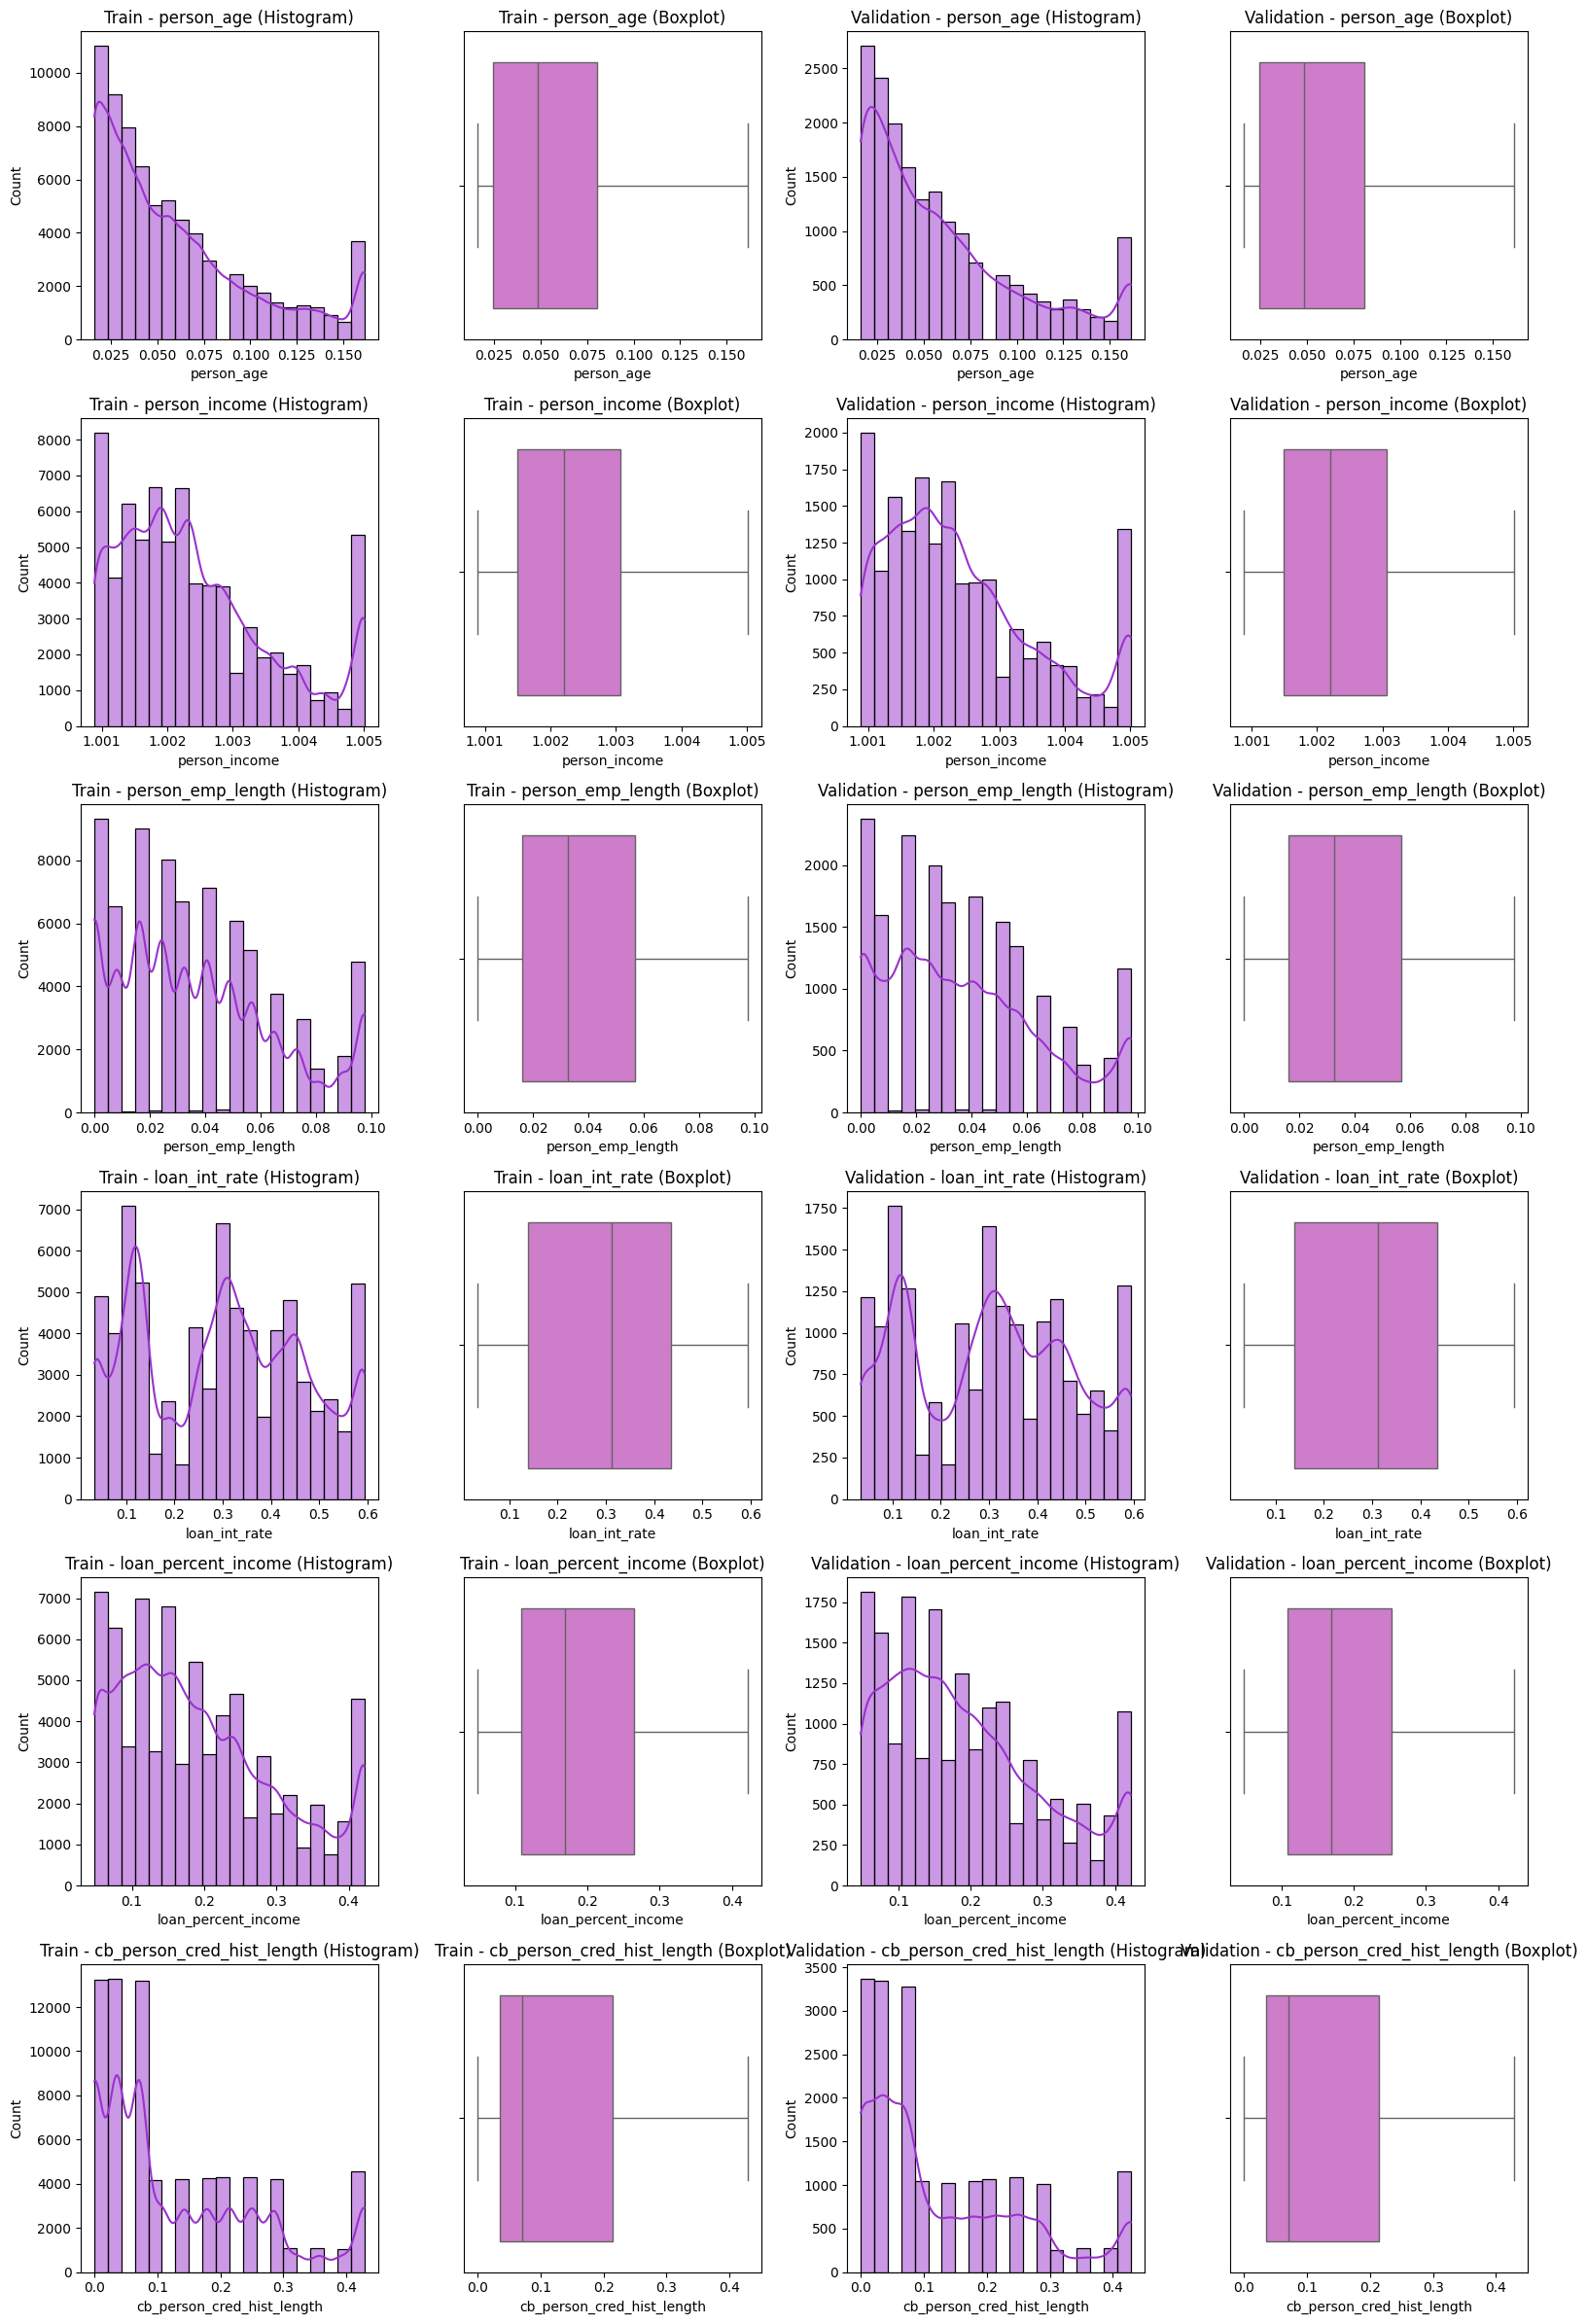

In [ ]:
# Create subplots: Two plots (hist + box) per column for both Train and Validation
fig, axes = plt.subplots(len(numerical_columns_no_target), 4, figsize=(16, len(numerical_columns_no_target) * 4))

for i, col in enumerate(numerical_columns_no_target):
    # Train Data (Left 2 Columns)
    plot_numerical_distribution(col, X_train_regress, axes=axes[i, :2])
    axes[i, 0].set_title(f"Train - {col} (Histogram)")
    axes[i, 1].set_title(f"Train - {col} (Boxplot)")

    # Validation Data (Right 2 Columns)
    plot_numerical_distribution(col, X_val_regress, axes=axes[i, 2:])
    axes[i, 2].set_title(f"Validation - {col} (Histogram)")
    axes[i, 3].set_title(f"Validation - {col} (Boxplot)")

plt.tight_layout()
plt.show()

### 8.2 Encoding

In [ ]:
# Apply Label Encoding to 'loan_grade' and 'cb_person_default_on_file'
label_encoder = LabelEncoder()

# Label Encode 'loan_grade' for X_train and X_val
X_train_regress['loan_grade'] = label_encoder.fit_transform(X_train_regress['loan_grade'])
X_val_regress['loan_grade'] = label_encoder.transform(X_val_regress['loan_grade'])

# Label Encode 'cb_person_default_on_file' for X_train and X_val
X_train_regress['cb_person_default_on_file'] = label_encoder.fit_transform(X_train_regress['cb_person_default_on_file'])
X_val_regress['cb_person_default_on_file'] = label_encoder.transform(X_val_regress['cb_person_default_on_file'])

# Apply One-Hot Encoding to 'person_home_ownership' and 'loan_intent' for X_train and X_val
X_train_regress = pd.get_dummies(X_train_regress, columns=['person_home_ownership', 'loan_intent'])
X_val_regress = pd.get_dummies(X_val_regress, columns=['person_home_ownership', 'loan_intent'])


### 8.3 Feature Creation

In [ ]:
def custom_scoring_reg(estimator, X, y):
    """
    Custom scoring function to calculate Mean Absolute Error (MAE) using predictions.
    """
    y_pred = estimator.predict(X)
    return -mean_absolute_error(y, y_pred)

def better_features_reg(X_train, y_train, X_val, y_val, cols):
    """
    Generate new features by combining columns from X_train using mathematical operations,
    and evaluate them using cross-validation with a custom scoring function (MAE).
    """
    new_cols = []  # List to store new columns
    kf = KFold(n_splits=5, shuffle=True, random_state=42)  # K-Fold Cross-Validation (for regression)

    # Iterate through all possible pairs of columns in `cols`
    for i in tqdm(range(len(cols)), desc='Generating Columns'):
        col1 = cols[i]
        temp_df = pd.DataFrame()  # Temporary dataframe to store generated columns
        temp_df_val = pd.DataFrame()  # Temporary dataframe for validation data

        # Generate combinations of columns and create new features
        for j in range(i + 1, len(cols)):
            col2 = cols[j]

            # Multiply
            temp_df[col1 + '*' + col2] = X_train[col1] * X_train[col2]
            temp_df_val[col1 + '*' + col2] = X_val[col1] * X_val[col2]

            # Divide (col1 / col2)
            temp_df[col1 + '/' + col2] = X_train[col1] / (X_train[col2] + 1e-5)
            temp_df_val[col1 + '/' + col2] = X_val[col1] / (X_val[col2] + 1e-5)

            # Divide (col2 / col1)
            temp_df[col2 + '/' + col1] = X_train[col2] / (X_train[col1] + 1e-5)
            temp_df_val[col2 + '/' + col1] = X_val[col2] / (X_val[col1] + 1e-5)

            # Subtract
            temp_df[col1 + '-' + col2] = X_train[col1] - X_train[col2]
            temp_df_val[col1 + '-' + col2] = X_val[col1] - X_val[col2]

            # Add
            temp_df[col1 + '+' + col2] = X_train[col1] + X_train[col2]
            temp_df_val[col1 + '+' + col2] = X_val[col1] + X_val[col2]

        # Model pipeline: StandardScaler followed by XGBRegressor
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('xgb', XGBRegressor())  # Using XGBRegressor for regression task
        ])

        SCORES = []  # List to store the scores of each new column

        # Evaluate each generated column using cross-validation
        for column in temp_df.columns:
            X_temp = temp_df[column].values.reshape(-1, 1)  # Reshape to fit the model
            y_temp = y_train  # Use y_train as target variable
            scores = cross_val_score(model, X_temp, y_temp, cv=kf, scoring=custom_scoring_reg)  # Use negative MAE as scoring
            mean_score = np.mean(scores)  # Calculate mean MAE
            SCORES.append((column, -mean_score))  # We negate the score because cross_val_score returns negative values for error metrics

        # If there are valid scores, find the best column based on the MAE
        if SCORES:
            best_col, best_score = sorted(SCORES, key=lambda x: x[1])[0]

            # Check for correlation with other columns to avoid multicollinearity
            corr_with_other_cols = X_train.drop(new_cols, axis=1).corrwith(temp_df[best_col])
            if (corr_with_other_cols.abs().max() < 0.9 or best_score > best_score) and corr_with_other_cols.abs().max() != 1:
                # Add the new feature to the training and validation sets
                X_train[best_col] = temp_df[best_col]
                X_val[best_col] = temp_df_val[best_col]
                new_cols.append(best_col)
                print(f"Added column '{best_col}' with MAE: {best_score:.4f} & Correlation {corr_with_other_cols.abs().max():.4f}")

    return X_train, X_val, new_cols


In [ ]:
%%time
selected_cols=[f for f in X_train_regress.columns if X_train_regress[f].nunique()>2]# select continuous columns to save runtime
X_train_regress, X_val_regress, new_cols = better_features_reg(X_train_regress, y_train_regress, X_val_regress, y_val_regress, selected_cols)

Generating Columns:  71%|███████▏  | 5/7 [01:54<00:37, 18.84s/it]

Added column 'loan_percent_income/loan_int_rate' with MAE: 0.7115 & Correlation 0.5867


Generating Columns: 100%|██████████| 7/7 [01:59<00:00, 17.05s/it]

Added column 'loan_percent_income-cb_person_cred_hist_length' with MAE: 0.6673 & Correlation 0.7734
CPU times: user 3min 30s, sys: 1.56 s, total: 3min 31s
Wall time: 1min 59s


In [ ]:
def evaluate_regressor(y_pred: np.ndarray, y_val: np.ndarray, plot_residuals: bool = True,
                       plot_pred_vs_actual: bool = True) -> Dict[str, float]:
    """
    Evaluates a regression model on validation data.

    Parameters:
    - y_pred: Predicted values from the model.
    - y_val: True target values for validation.
    - plot_residuals: Boolean to plot residuals (default True).
    - plot_pred_vs_actual: Boolean to plot predicted vs actual values (default True).

    Returns:
    - metrics: Dictionary containing 'mae', 'mse', 'rmse', 'r2' scores.
    """
    # Calculate regression metrics
    mae: float = mean_absolute_error(y_val, y_pred)
    mse: float = mean_squared_error(y_val, y_pred)
    rmse: float = np.sqrt(mse)
    r2: float = r2_score(y_val, y_pred)

    # Store metrics in a dictionary
    metrics: Dict[str, float] = {
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'r2': r2
    }

    # Print metrics
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R2): {r2:.4f}")

    # Plot residuals
    if plot_residuals:
        residuals = y_val - y_pred
        plt.figure(figsize=(8, 6))
        sns.histplot(residuals, kde=True, color='blue', bins=30)
        plt.axvline(x=0, color='gray', linestyle='--')
        plt.xlabel('Residuals')
        plt.ylabel('Frequency')
        plt.title('Residuals Distribution')
        plt.show()

    # Plot predicted vs actual values
    if plot_pred_vs_actual:
        plt.figure(figsize=(8, 6))
        plt.scatter(y_val, y_pred, color='blue', alpha=0.6)
        plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color='red', linestyle='--')
        plt.xlabel('Actual Values')
        plt.ylabel('Predicted Values')
        plt.title('Predicted vs Actual Values')
        plt.show()

    return metrics


def find_best_pca_components(X_train: np.ndarray, y_train: np.ndarray, max_components: int = None,
                             scoring: str = 'r2', cv: int = 5) -> int:
    """
    Finds the optimal number of PCA components using cross-validation for a regression problem.

    Parameters:
    - X_train: Training feature matrix.
    - y_train: Training labels.
    - max_components: Maximum number of components to test (default: min(n_features, 100)).
    - scoring: Scoring metric for cross-validation (default: 'r2').
    - cv: Number of cross-validation folds (default: 5).

    Returns:
    - optimal_n: Optimal number of PCA components.
    """
    if max_components is None:
        max_components = min(X_train.shape[1], 100)  # Limit to a maximum of 100 components or number of features

    scores = []
    components_range = range(1, max_components + 1)

    for n in components_range:
        pca = PCA(n_components=n)
        X_pca = pca.fit_transform(X_train)

        # Use Lasso with a very small alpha for regression CV
        model = Lasso(alpha=1e-5)
        cv_score = cross_val_score(model, X_pca, y_train, cv=cv, scoring=scoring).mean()
        scores.append(cv_score)

    # For a metric like r2, higher is better
    optimal_n = components_range[np.argmax(scores)]

    # Plot CV scores vs. number of components
    plt.figure(figsize=(8, 5))
    plt.plot(components_range, scores, marker='o', linestyle='-')
    plt.xlabel("Number of PCA Components")
    plt.ylabel(scoring.upper())
    plt.title(f"Cross-Validation {scoring.upper()} vs. Number of PCA Components")
    plt.axvline(optimal_n, color='r', linestyle='--', label=f"Optimal: {optimal_n}")
    plt.legend()
    plt.show()

    return optimal_n


def apply_pca(optimal_n: int, X_train: np.ndarray, X_val: np.ndarray) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """
    Applies PCA using the optimal number of components for a regression problem.

    Parameters:
    - optimal_n: Number of PCA components to keep.
    - X_train: Training feature matrix.
    - X_val: Validation feature matrix.

    Returns:
    - X_train_pca: Transformed training set.
    - X_val_pca: Transformed validation set.
    - pca_df: DataFrame containing PCA component loadings for interpretation.
    """
    pca = PCA(n_components=optimal_n)

    # Fit PCA on training data and transform both train and validation sets
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)

    # Create DataFrame to interpret principal components
    # (Make sure X_train is a DataFrame so that X_train.columns exists)
    pca_df = pd.DataFrame(
        data=pca.components_,
        columns=X_train.columns,
        index=[f'PC{x+1}' for x in range(optimal_n)]
    )

    return X_train_pca, X_val_pca, pca_df


def top_features_for_pc(pca_df: pd.DataFrame, pc_name: str, top_n: int = 5) -> List[str]:
    """
    Returns the top N original features contributing to a specific principal component.

    Parameters:
    - pca_df (pd.DataFrame): DataFrame containing PCA component loadings.
    - pc_name (str): Principal component name (e.g., "PC1").
    - top_n (int): Number of top features to return (default is 5).

    Returns:
    - List[str]: List of top N feature names contributing to the given PC.
    """
    if pc_name not in pca_df.index:
        raise ValueError(f"{pc_name} not found in PCA DataFrame index.")

    # Get absolute loadings and sort descending
    sorted_features = pca_df.loc[pc_name].abs().sort_values(ascending=False)
    return sorted_features.index[:top_n].tolist()


def plot_history(history) -> None:
    # Plot training and validation loss (e.g., MSE)
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.show()

    # Check if a regression metric (e.g., mean_absolute_error) is present in the history
    metric_key = None
    for key in history.history.keys():
        if 'mae' in key:  # could be 'mean_absolute_error' or simply 'mae'
            metric_key = key
            break

    if metric_key is not None:
        # Determine the corresponding validation metric key
        val_metric_key = 'val_' + metric_key if not metric_key.startswith('val_') else metric_key.replace('val_', '')
        plt.figure(figsize=(8, 5))
        plt.plot(history.history[metric_key], label='Train ' + metric_key.upper())
        plt.plot(history.history[val_metric_key], label='Validation ' + val_metric_key.upper())
        plt.title(f'Training vs Validation {metric_key.upper()}')
        plt.xlabel('Epoch')
        plt.ylabel(metric_key.upper())
        plt.legend(loc='upper right')
        plt.show()



### 8.4 Linear Regression + Lasso

Mean Absolute Error (MAE): 0.5515
Mean Squared Error (MSE): 0.5274
Root Mean Squared Error (RMSE): 0.7262
R-squared (R2): 0.4702


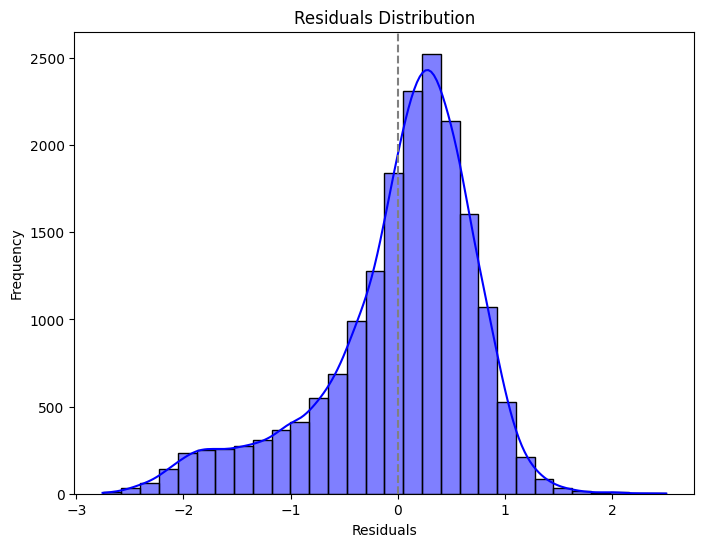

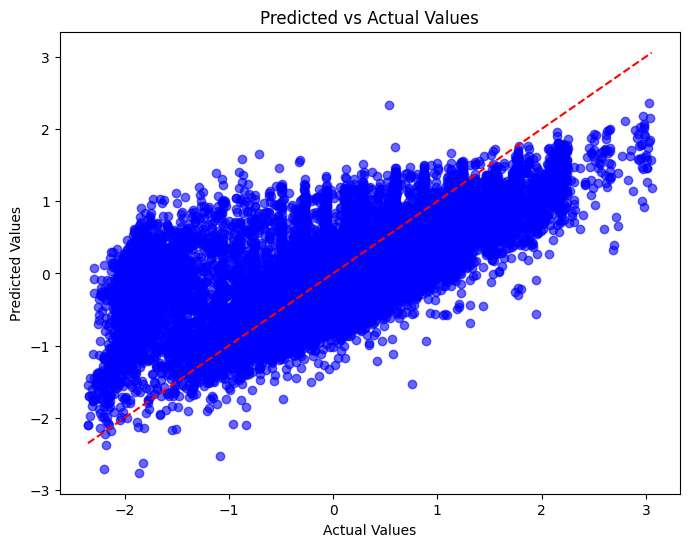

In [ ]:
# Uncomment to do Grid Search


# param_grid = {
#     'alpha': np.arange(1e-5, 0.01, 0.00005)
# }

# # Initialize a Lasso model
# lasso = Lasso()

# # Use GridSearchCV to tune alpha using 5-fold CV and negative MSE as the scoring metric
# grid_search = GridSearchCV(lasso, param_grid, scoring='neg_mean_squared_error', cv=5)
# grid_search.fit(X_train_regress, y_train_regress)

# print("Best alpha:", grid_search.best_params_['alpha'])
# best_alpha = grid_search.best_params_['alpha']




best_alpha = 1e-5
lasso_best = Lasso(alpha=best_alpha)
lasso_best.fit(X_train_regress, y_train_regress)

# Predict using the validation set
y_pred = lasso_best.predict(X_val_regress)

# Evaluate the model performance using the evaluate_regressor function
metrics_lasso = evaluate_regressor(y_pred, y_val_regress)

### 8.4 Linear Regression + Lasso on PCA

In [ ]:
# optimal_n_components_reg = find_best_pca_components(X_train_regress,y_train_regress)
optimal_n_components_reg = 18
print(f"Optimal number of PCA components: {optimal_n_components_reg}")

Optimal number of PCA components: 18


In [ ]:
X_train_regress_pca, X_val_regress_pca, pca_regress_df = apply_pca(optimal_n_components_reg, X_train_regress, X_val_regress)

print("PCA Transformed Train Shape:", X_train_regress_pca.shape)
print("PCA Transformed Val Shape:", X_val_regress_pca.shape)
print("\nPCA Component Loadings:")
display(pca_regress_df.head())  # Display first few principal components

PCA Transformed Train Shape: (72872, 18)
PCA Transformed Val Shape: (18240, 18)

PCA Component Loadings:


,person_age,person_income,person_emp_length,loan_grade,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,original,person_home_ownership_MORTGAGE,...,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_percent_income/loan_int_rate,loan_percent_income-cb_person_cred_hist_length
PC1,-0.000507,-0.000047,0.001574,-0.534872,-0.089592,0.012092,-0.095776,-0.001341,-0.009879,0.046171,...,0.004433,-0.050107,0.001942,0.000411,-0.004281,-0.001564,0.002347,0.001144,0.831619,0.013432
PC2,-0.000827,-0.000265,-0.002446,0.788186,0.086359,0.051310,0.173162,-0.002728,0.050914,-0.127300,...,0.005693,0.121414,0.000808,-0.003313,0.004422,0.007986,-0.005069,-0.004835,0.549580,0.054038
PC3,-0.003863,-0.000547,-0.011667,-0.178107,-0.012436,0.013472,-0.045447,-0.010673,-0.035282,-0.683908,...,-0.013521,0.698066,0.000015,0.009540,-0.044241,0.065434,-0.014462,-0.016286,-0.042073,0.024145
PC4,0.001857,-0.000008,0.000276,-0.050349,-0.007601,0.003837,-0.020303,0.001219,0.992033,-0.038609,...,0.039316,-0.002501,0.017508,-0.085455,0.004437,0.023270,0.007336,0.032903,-0.022064,0.002617
PC5,-0.011753,-0.000013,-0.001988,-0.005405,0.000235,0.001798,0.005186,-0.031350,0.092335,-0.012413,...,0.006738,0.005829,-0.101103,0.872083,-0.035449,-0.401390,-0.165051,-0.169090,-0.001802,0.033148


In [ ]:
top_regress_features = top_features_for_pc(pca_regress_df, "PC8")
print(top_regress_features)

['loan_intent_DEBTCONSOLIDATION', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_intent_MEDICAL', 'person_home_ownership_OWN']


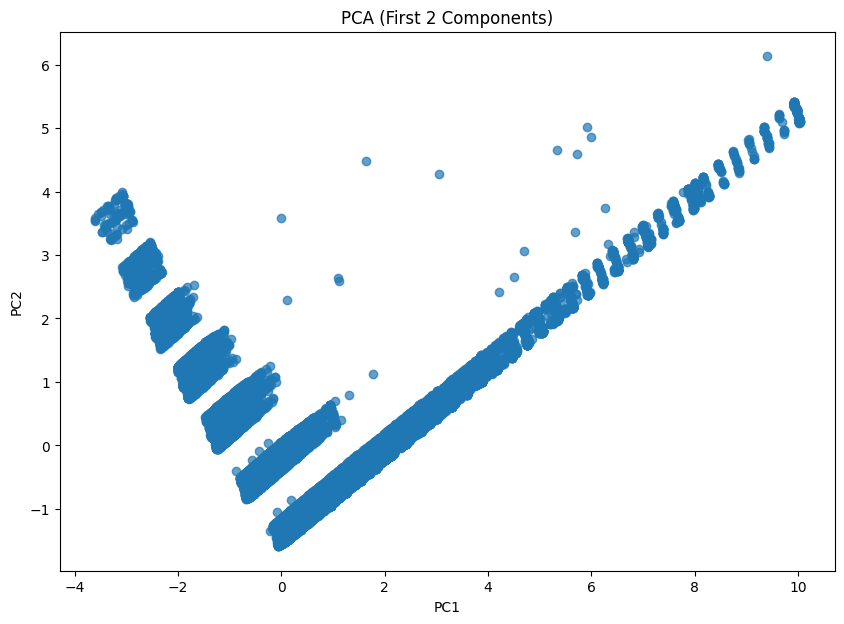

In [ ]:
# Create DataFrames for plotting all PCA components
X_train_regress_pca_df = pd.DataFrame(X_train_regress_pca, columns=[f'PC{i+1}' for i in range(X_train_regress_pca.shape[1])])
X_val_regress_pca_df = pd.DataFrame(X_val_regress_pca, columns=[f'PC{i+1}' for i in range(X_val_regress_pca.shape[1])])

# Add labels to the DataFrames (optional, based on y_train and y_val)
X_train_regress_pca_df['Label'] = y_train_regress
X_val_regress_pca_df['Label'] = y_val_regress

# Concatenate the training and validation DataFrames
X_combined_regress_pca_df = pd.concat([X_train_regress_pca_df, X_val_regress_pca_df], axis=0)

# Plot PCA for both X_train and X_val together (only first 2 components for visualization)
plt.figure(figsize=(10, 7))
scatter_combined = plt.scatter(
    X_combined_regress_pca_df['PC1'], X_combined_regress_pca_df['PC2'],
     cmap='coolwarm', alpha=0.7
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA (First 2 Components)')
plt.show()


Mean Absolute Error (MAE): 0.5515
Mean Squared Error (MSE): 0.5274
Root Mean Squared Error (RMSE): 0.7262
R-squared (R2): 0.4702


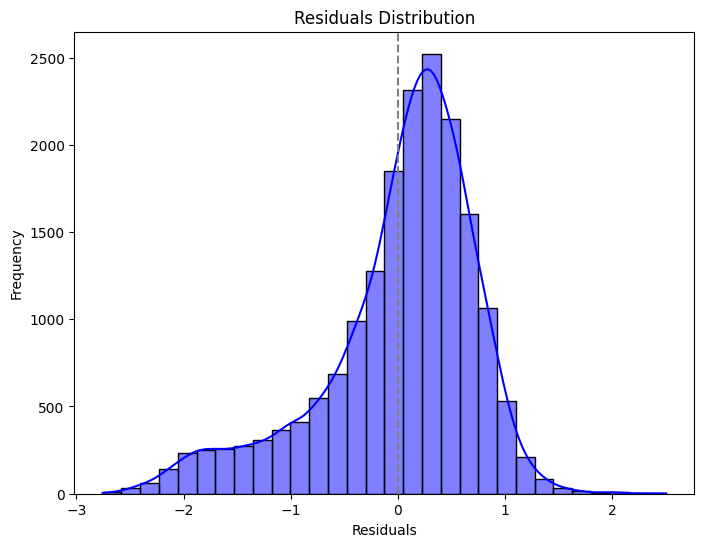

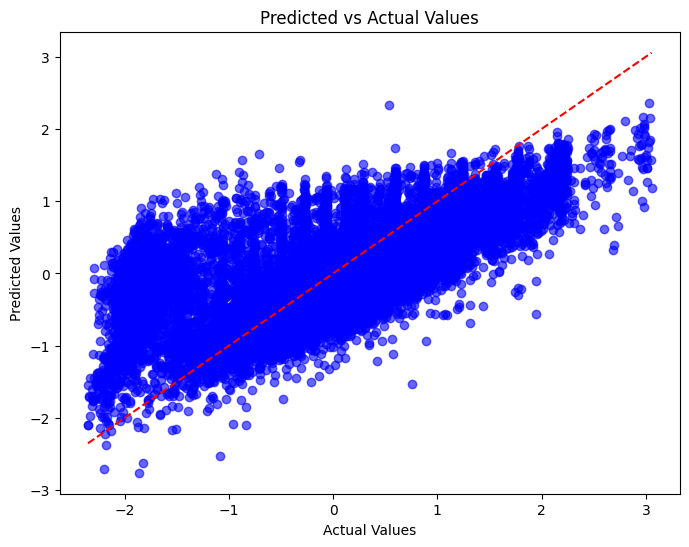

In [ ]:
lasso_pca = Lasso(alpha=best_alpha)
lasso_pca.fit(X_train_regress_pca, y_train_regress)

# Predict using the validation set
y_pred = lasso_pca.predict(X_val_regress_pca)

# Evaluate the model performance using the evaluate_regressor function
metrics_lasso_pca = evaluate_regressor(y_pred, y_val_regress)

### 8.5 XGBOOST

Mean Absolute Error (MAE): 0.0950
Mean Squared Error (MSE): 0.0341
Root Mean Squared Error (RMSE): 0.1846
R-squared (R2): 0.9658


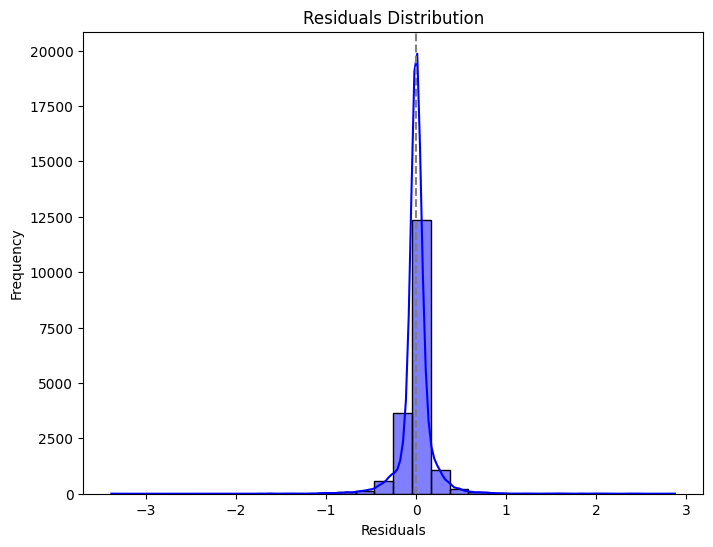

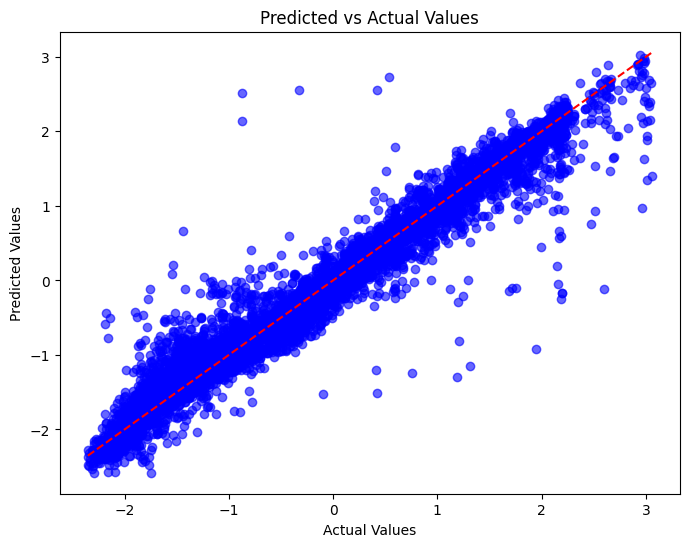

In [ ]:
# Uncomment the block below to run Grid Search for XGBoost hyperparameters

# param_grid_xgb = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [3, 4, 5],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'subsample': [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0]
# }

# xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
# grid_search_xgb = GridSearchCV(xgb, param_grid_xgb, scoring='neg_mean_squared_error', cv=5)
# grid_search_xgb.fit(X_train_regress, y_train_regress)

# print("Best parameters for XGBoost:", grid_search_xgb.best_params_)
# best_xgb = grid_search_xgb.best_estimator_

best_params = {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
best_xgb = XGBRegressor(objective='reg:squarederror', random_state=42, **best_params)

# Fit the model on the training data (already scaled)
best_xgb.fit(X_train_regress, y_train_regress)

# Predict using the validation set
y_val_regress_pred_xgb = best_xgb.predict(X_val_regress)

# Evaluate the model performance using the evaluate_regressor function
metrics_xgb = evaluate_regressor(y_val_regress_pred_xgb, y_val_regress)


### 8.5 XGBOOST on PCA

Mean Absolute Error (MAE): 0.1637
Mean Squared Error (MSE): 0.0809
Root Mean Squared Error (RMSE): 0.2844
R-squared (R2): 0.9187


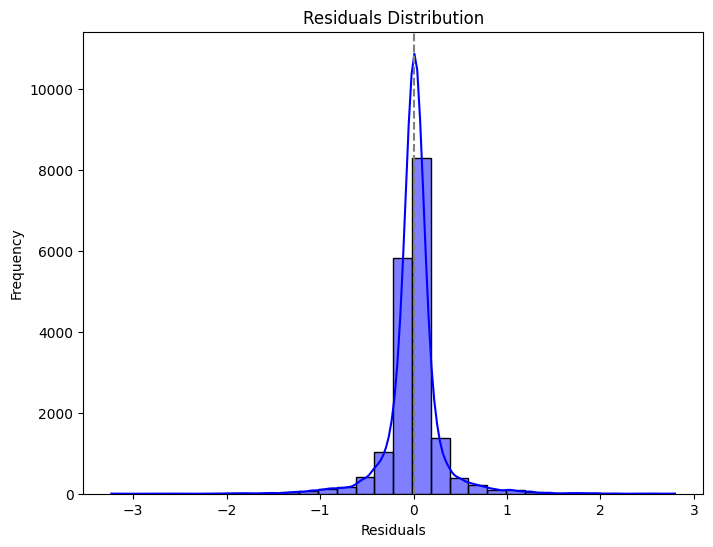

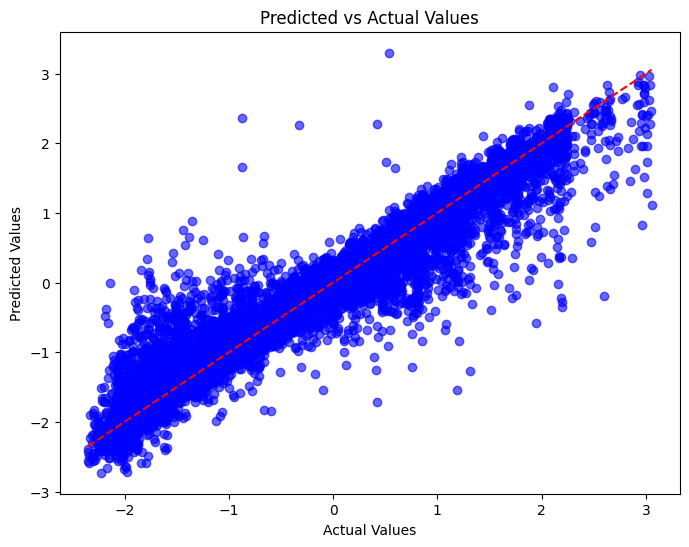

In [ ]:
best_xgb.fit(X_train_regress_pca, y_train_regress)

# Predict using the validation set
y_pred = best_xgb.predict(X_val_regress_pca)

# Evaluate the model performance using the evaluate_regressor function
metrics_xgb_pca = evaluate_regressor(y_pred, y_val_regress)

### 8.6 Neural Network

In [ ]:
model = Sequential()

# Input layer: 128 neurons to capture complex patterns from the inputs
model.add(Dense(128, input_dim=X_train_regress.shape[1], activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Hidden layer: 128 neurons
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Hidden layer: 64 neurons to gradually reduce dimensionality
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Hidden layer: 32 neurons for further feature refinement
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Output layer: 1 neuron with linear activation for regression output
model.add(Dense(1, activation='linear'))


In [ ]:
# Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           2,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,105 (121.50 KB)

 Trainable params: 30,401 (118.75 KB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
# Visualize model structure
# tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True)

In [ ]:
# Compile the model with the Adam optimizer and specified learning rate
learning_rate = 0.0001
optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mean_squared_error'])

In [ ]:
# Add early stopping to avoid overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [ ]:
# Train the model
history = model.fit(X_train_regress, y_train_regress,
                    validation_data=(X_val_regress, y_val_regress),
                    epochs=20,
                    batch_size=32,
                    callbacks=[early_stopping],
                    verbose=1)

Epoch 1/20
2264/2278 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1010 - mean_squared_error: 2.1010

KeyboardInterrupt: 

In [ ]:
plot_history(history)

In [ ]:
# # Predict using the validation set
# y_pred = model.predict(X_val_regress)

# # Evaluate the model performance using the evaluate_regressor function
# metrics_nn = evaluate_regressor(y_pred, y_val_regress)

### Model Comparison

In [ ]:
# models_reg = {
#     "Lasso Regression": metrics_lasso
#     ,"Lasso Regression (PCA)": metrics_lasso_pca
#     ,"XGBoost": metrics_xgb
#     ,"XGBoost (PCA)": metrics_xgb_pca
#     ,"Neural Network": metrics_nn
# }

# Define the metrics for each model
models_reg = {
    "Lasso Regression": {"mae": 0.5484, "mse": 0.5245, "rmse": 0.7242, "r2": 0.4732},
    "Lasso Regression (PCA)": {"mae": 0.5484, "mse": 0.5245, "rmse": 0.7242, "r2": 0.4732},
    "XGBoost": {"mae": 0.0942, "mse": 0.0336, "rmse": 0.1834, "r2": 0.9662},
    "XGBoost (PCA)": {"mae": 0.1619, "mse": 0.0797, "rmse": 0.2823, "r2": 0.9199},
    "Neural Network": {"mae": 0.4632, "mse": 0.3663, "rmse": 0.6053, "r2": 0.6321}
}

# Create a PrettyTable
table = PrettyTable()
table.field_names = ["Model", "MAE", "MSE", "RMSE", "R_squared"]

# Populate the table
for model_name, metrics in models_reg.items():
    table.add_row([
        model_name,
        round(metrics["mae"], 4),
        round(metrics["mse"], 4),
        round(metrics["rmse"], 4),
        round(metrics["r2"], 4)
    ])

# Print the table
print(table)


+------------------------+--------+--------+--------+-----------+
|         Model          |  MAE   |  MSE   |  RMSE  | R_squared |
+------------------------+--------+--------+--------+-----------+
|    Lasso Regression    | 0.5484 | 0.5245 | 0.7242 |   0.4732  |
| Lasso Regression (PCA) | 0.5484 | 0.5245 | 0.7242 |   0.4732  |
|        XGBoost         | 0.0942 | 0.0336 | 0.1834 |   0.9662  |
|     XGBoost (PCA)      | 0.1619 | 0.0797 | 0.2823 |   0.9199  |
|     Neural Network     | 0.4632 | 0.3663 | 0.6053 |   0.6321  |
+------------------------+--------+--------+--------+-----------+


### Model Interpretation

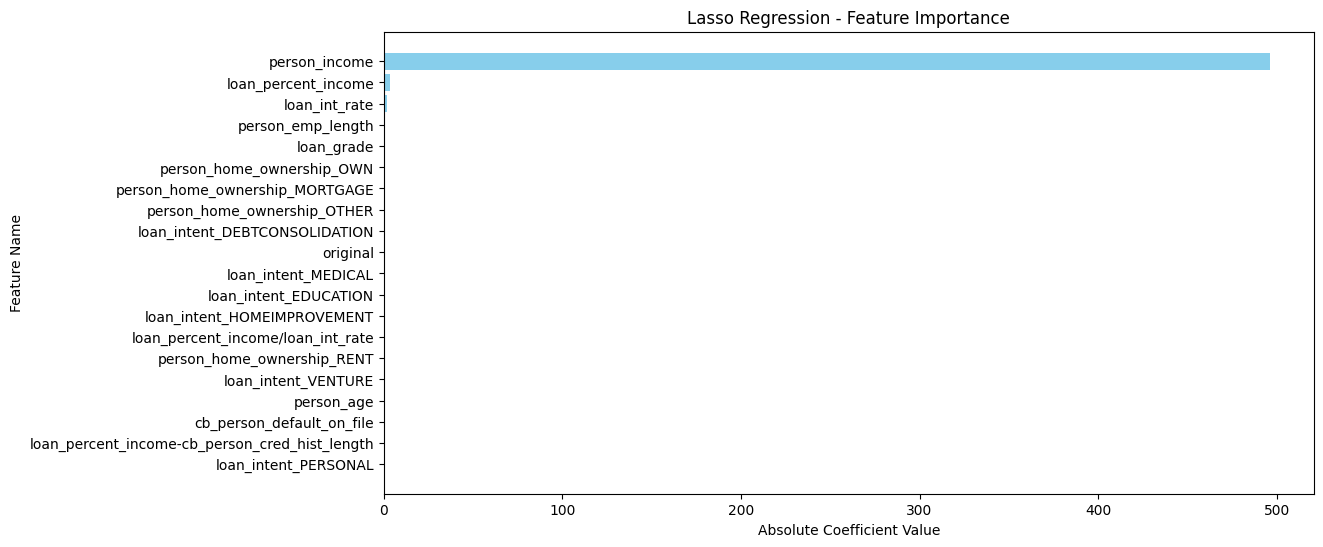

In [ ]:
# Extract feature names and corresponding Lasso coefficients
feature_importance = np.abs(lasso_best.coef_)
feature_names = X_train_regress.columns  # Assuming X_train_regress is a DataFrame

# Sort features by importance
sorted_idx = np.argsort(feature_importance)[::-1]  # Sort in descending order
sorted_features = np.array(feature_names)[sorted_idx]
sorted_importance = feature_importance[sorted_idx]

# Plot feature importances
plt.figure(figsize=(12, 6))
plt.barh(sorted_features[:20], sorted_importance[:20], color='skyblue')  # Top 20 features
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature Name")
plt.title("Lasso Regression - Feature Importance")
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.show()


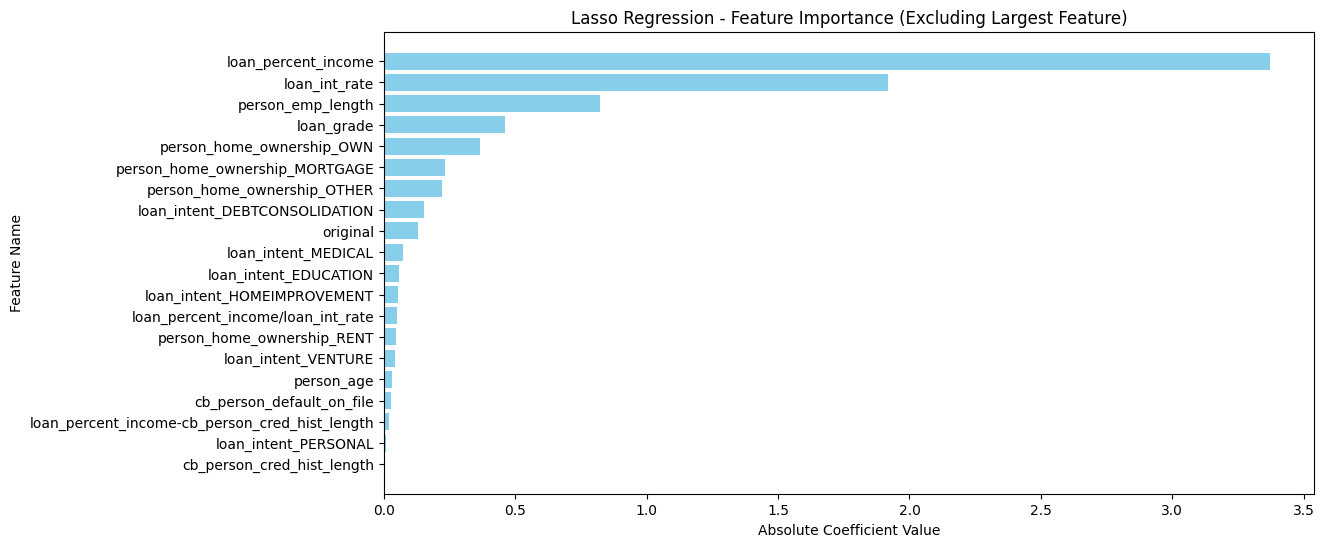

In [ ]:
# Extract feature names and corresponding Lasso coefficients
feature_importance = np.abs(lasso_best.coef_)
feature_names = X_train_regress.columns  # Assuming X_train_regress is a DataFrame

# Sort features by importance
sorted_idx = np.argsort(feature_importance)[::-1]  # Sort in descending order
sorted_features = np.array(feature_names)[sorted_idx]
sorted_importance = feature_importance[sorted_idx]

# Remove the largest feature importance (first element)
sorted_features = sorted_features[1:]
sorted_importance = sorted_importance[1:]

# Plot feature importances (excluding the largest feature)
plt.figure(figsize=(12, 6))
plt.barh(sorted_features[:20], sorted_importance[:20], color='skyblue')  # Top 20 features after removal
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature Name")
plt.title("Lasso Regression - Feature Importance (Excluding Largest Feature)")
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.show()


In [ ]:
# Get the intercept and coefficients from the trained Lasso model
intercept = lasso_best.intercept_
coefficients = lasso_best.coef_

# Print the regression equation
equation = f"y = {intercept:.4f}"
for feature, coef in zip(X_train_regress.columns, coefficients):
    if coef != 0:  # Only include non-zero coefficients (as Lasso can shrink some to 0)
        equation += f" + ({coef:.4f}) * {feature}"

print("Lasso Regression Equation:")
print(equation)


Lasso Regression Equation:
y = -498.1071 + (-0.0318) * person_age + (496.0818) * person_income + (0.8229) * person_emp_length + (-0.4599) * loan_grade + (1.9194) * loan_int_rate + (3.3704) * loan_percent_income + (0.0278) * cb_person_default_on_file + (-0.1299) * original + (0.2327) * person_home_ownership_MORTGAGE + (0.2215) * person_home_ownership_OTHER + (0.3644) * person_home_ownership_OWN + (-0.0477) * person_home_ownership_RENT + (-0.1520) * loan_intent_DEBTCONSOLIDATION + (0.0585) * loan_intent_EDUCATION + (-0.0538) * loan_intent_HOMEIMPROVEMENT + (-0.0740) * loan_intent_MEDICAL + (0.0064) * loan_intent_PERSONAL + (0.0420) * loan_intent_VENTURE + (0.0483) * loan_percent_income/loan_int_rate + (0.0212) * loan_percent_income-cb_person_cred_hist_length


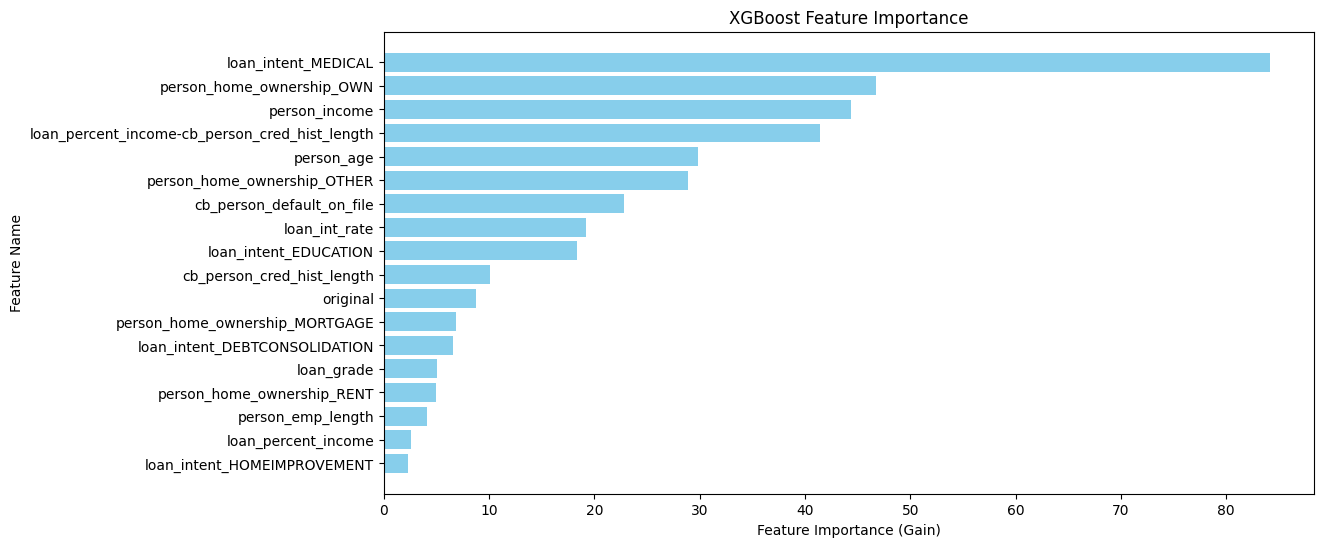

In [ ]:
# Assuming X_train_regress is a pandas DataFrame
feature_names = X_train_regress.columns

# Get the importance scores from the trained XGBoost model
xgb_importance = best_xgb.get_booster().get_score(importance_type="gain")

# Sort the importance values
sorted_importance = sorted(xgb_importance.items(), key=lambda x: x[1], reverse=True)

# Extract feature names and their importance values
features, importance_values = zip(*sorted_importance)

# Map the numeric features back to the original names
features = [feature_names[int(f[1:]) - 1] for f in features]

# Plot the top 20 features
plt.figure(figsize=(12, 6))
plt.barh(features[:20], importance_values[:20], color='skyblue')
plt.xlabel("Feature Importance (Gain)")
plt.ylabel("Feature Name")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()


100%|===================| 18192/18240 [01:40<00:00]       

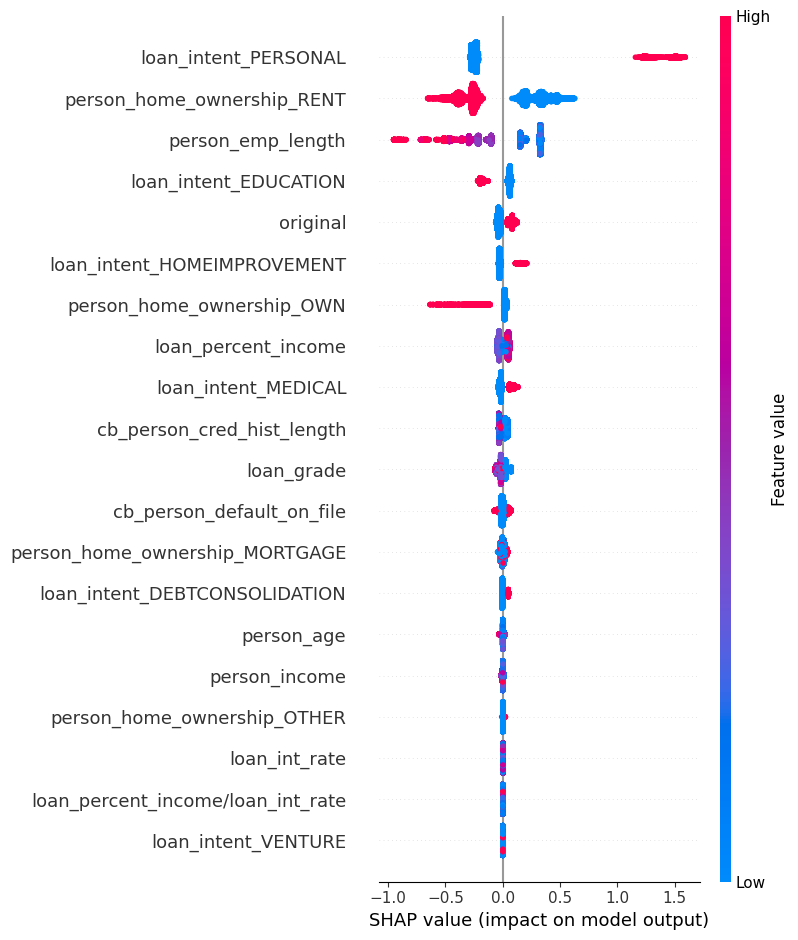

In [ ]:
# Convert all columns to float64 to avoid any type mismatch
X_train_regress = X_train_regress.astype('float64')
X_val_regress = X_val_regress.astype('float64')

# Initialize SHAP explainer
explainer = shap.Explainer(best_xgb, X_train_regress)
shap_values = explainer(X_val_regress)  # Compute SHAP values for validation set

# Summary plot: Shows overall importance + feature effects
shap.summary_plot(shap_values, X_val_regress)

y = -498.1071 + (-0.0318) * person_age + (496.0818) * person_income + (0.8229) * person_emp_length + (-0.4599) * loan_grade + (1.9194) * loan_int_rate + (3.3704) * loan_percent_income + (0.0278) * cb_person_default_on_file + (-0.1299) * original + (0.2327) * person_home_ownership_MORTGAGE + (0.2215) * person_home_ownership_OTHER + (0.3644) * person_home_ownership_OWN + (-0.0477) * person_home_ownership_RENT + (-0.1520) * loan_intent_DEBTCONSOLIDATION + (0.0585) * loan_intent_EDUCATION + (-0.0538) * loan_intent_HOMEIMPROVEMENT + (-0.0740) * loan_intent_MEDICAL + (0.0064) * loan_intent_PERSONAL + (0.0420) * loan_intent_VENTURE + (0.0483) * loan_percent_income/loan_int_rate + (0.0212) * loan_percent_income-cb_person_cred_hist_length

